In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time

import torch
import numpy as np
import pandas as pd

#plotting
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
# own libraries
import DDQN
import PPO_SIL

from HJBQVI_solver import solve_exchange_rate_explicit_impulse

In [4]:
USE_MPS = torch.backends.mps.is_available()
DEVICE = torch.device('mps' if USE_MPS else ('cuda' if torch.cuda.is_available() else 'cpu'))
torch.set_default_dtype(torch.float32 if DEVICE.type=='mps' else torch.float64)

In [5]:
#common parameters across models
common = dict(
    w_const=0.05,
    mu=0.25,
    sigma=0.30,
    beta=0.02,
    gamma=3.0,
    kappa=1.0,
    c=0.10,
    T=1.0,
    m=0.02,
)

# 1. Explicit-impulse scheme

## 1.1 Test run

In [6]:
n_x = 32
n_t = 16
n_zeta = 16

res = solve_exchange_rate_explicit_impulse(
    w_const=common['w_const'],
    mu=common['mu'],
    sigma=common['sigma'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],
    n_x=n_x,
    m=common['m'],
    n_zeta=n_zeta,
    n_t=n_t,
)

x_grid = res.x_grid
v_m_0 = res.values[0]
print(f'v(0,m): {float(np.interp(common['m'], x_grid, v_m_0))}')

v(0,m): -0.05748819807515052


## 1.2 Convergence test

In [7]:
h_arr = [2**i for i in range(0,7)]
prev_sol = None
ratio = 0

for h in h_arr:
    start_time = time.perf_counter()
    
    res_convergence_test = solve_exchange_rate_explicit_impulse(
        w_const=common['w_const'],
        mu=common['mu'],
        sigma=common['sigma'],
        beta=common['beta'],
        gamma=common['gamma'],
        kappa=common['kappa'],
        c=common['c'],
        T=common['T'],
        m=common['m'],
        n_x=int(n_x*h),
        n_zeta=int(n_zeta*h),
        n_t=int(n_t*h),
    )
    
    x_grid = res_convergence_test.x_grid
    v_0_m = float(np.interp(common['m'], x_grid, res_convergence_test.values[0]))

    if(prev_sol is not None):
        ratio = v_0_m/prev_sol

    prev_sol = v_0_m
    end_time = time.perf_counter()
    time_elapsed = end_time - start_time

    print(f'h={int(h)} | n_t={int(n_t*h)} | n_x={int(n_x*h)} | n_zeta={int(n_zeta*h)} | v(0,m)={v_0_m:.6f} | Ratio: {ratio:.2f} | Time elapsed (s): {time_elapsed:.2e}')

h=1 | n_t=16 | n_x=32 | n_zeta=16 | v(0,m)=-0.057488 | Ratio: 0.00 | Time elapsed (s): 1.96e-03
h=2 | n_t=32 | n_x=64 | n_zeta=32 | v(0,m)=-0.054501 | Ratio: 0.95 | Time elapsed (s): 2.47e-03
h=4 | n_t=64 | n_x=128 | n_zeta=64 | v(0,m)=-0.052996 | Ratio: 0.97 | Time elapsed (s): 1.05e-02
h=8 | n_t=128 | n_x=256 | n_zeta=128 | v(0,m)=-0.052377 | Ratio: 0.99 | Time elapsed (s): 2.12e-02
h=16 | n_t=256 | n_x=512 | n_zeta=256 | v(0,m)=-0.052120 | Ratio: 1.00 | Time elapsed (s): 1.18e-01
h=32 | n_t=512 | n_x=1024 | n_zeta=512 | v(0,m)=-0.051995 | Ratio: 1.00 | Time elapsed (s): 1.42e+00
h=64 | n_t=1024 | n_x=2048 | n_zeta=1024 | v(0,m)=-0.051938 | Ratio: 1.00 | Time elapsed (s): 1.07e+01


## 1.3 Plot

### 1.3.1 2D Plot

In [ ]:
n_x = 401
n_t = 252
n_zeta = 101

res = solve_exchange_rate_explicit_impulse(
    w_const=common['w_const'],
    mu=common['mu'],
    sigma=common['sigma'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],
    n_x=n_x,
    m=common['m'],
    n_zeta=n_zeta,
    n_t=n_t,
)

x_grid = res.x_grid
v_m_0 = res.values[0]
print(f'v(0,m): {float(np.interp(common['m'], x_grid, v_m_0))}')

v(0,m): -0.05214544082368151


In [52]:
%%timeit
res = solve_exchange_rate_explicit_impulse(
    w_const=common['w_const'],
    mu=common['mu'],
    sigma=common['sigma'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],
    n_x=n_x,
    m=common['m'],
    n_zeta=n_zeta,
    n_t=n_t,
)

36.6 ms ± 2.58 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


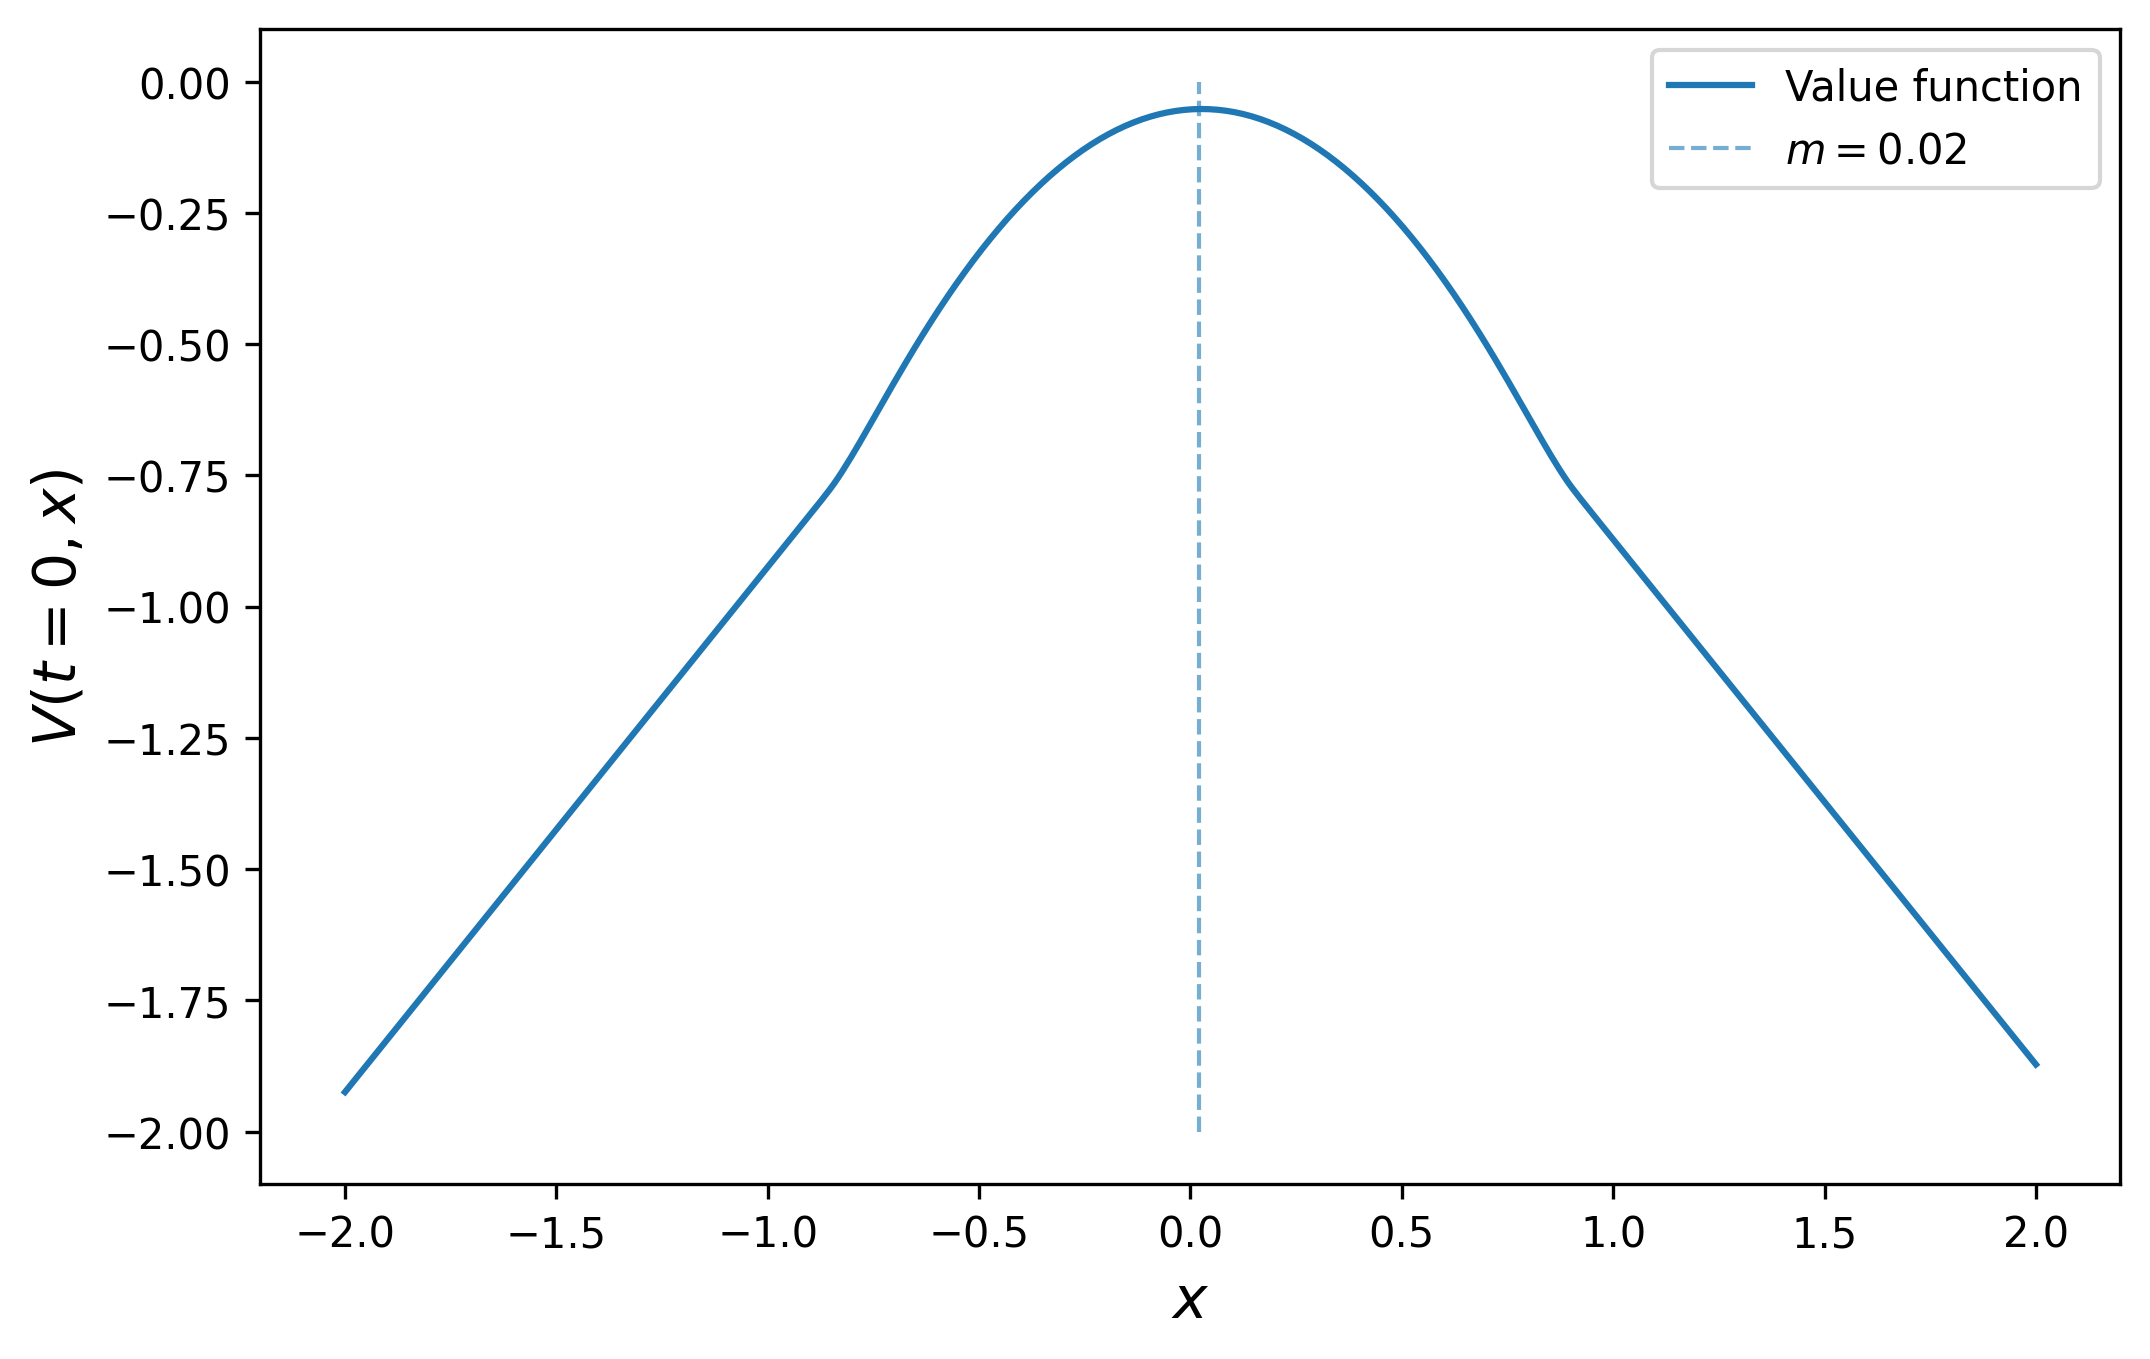

In [48]:
plt.figure(figsize=(8,5), dpi=300)
plt.plot(x_grid, v_m_0, label='Value function')
plt.vlines(common['m'], ymax=0.0, ymin=-2, linestyles='--', linewidth=1.0, alpha=0.6, label=rf'$m={common['m']}$')
#plt.title(r'Value function $V$ at time $t=0$ and $x \in [-2,2]$')
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$V(t=0,x)$', fontsize=14)
plt.legend()
plt.show()

### 1.3.2 3D plot

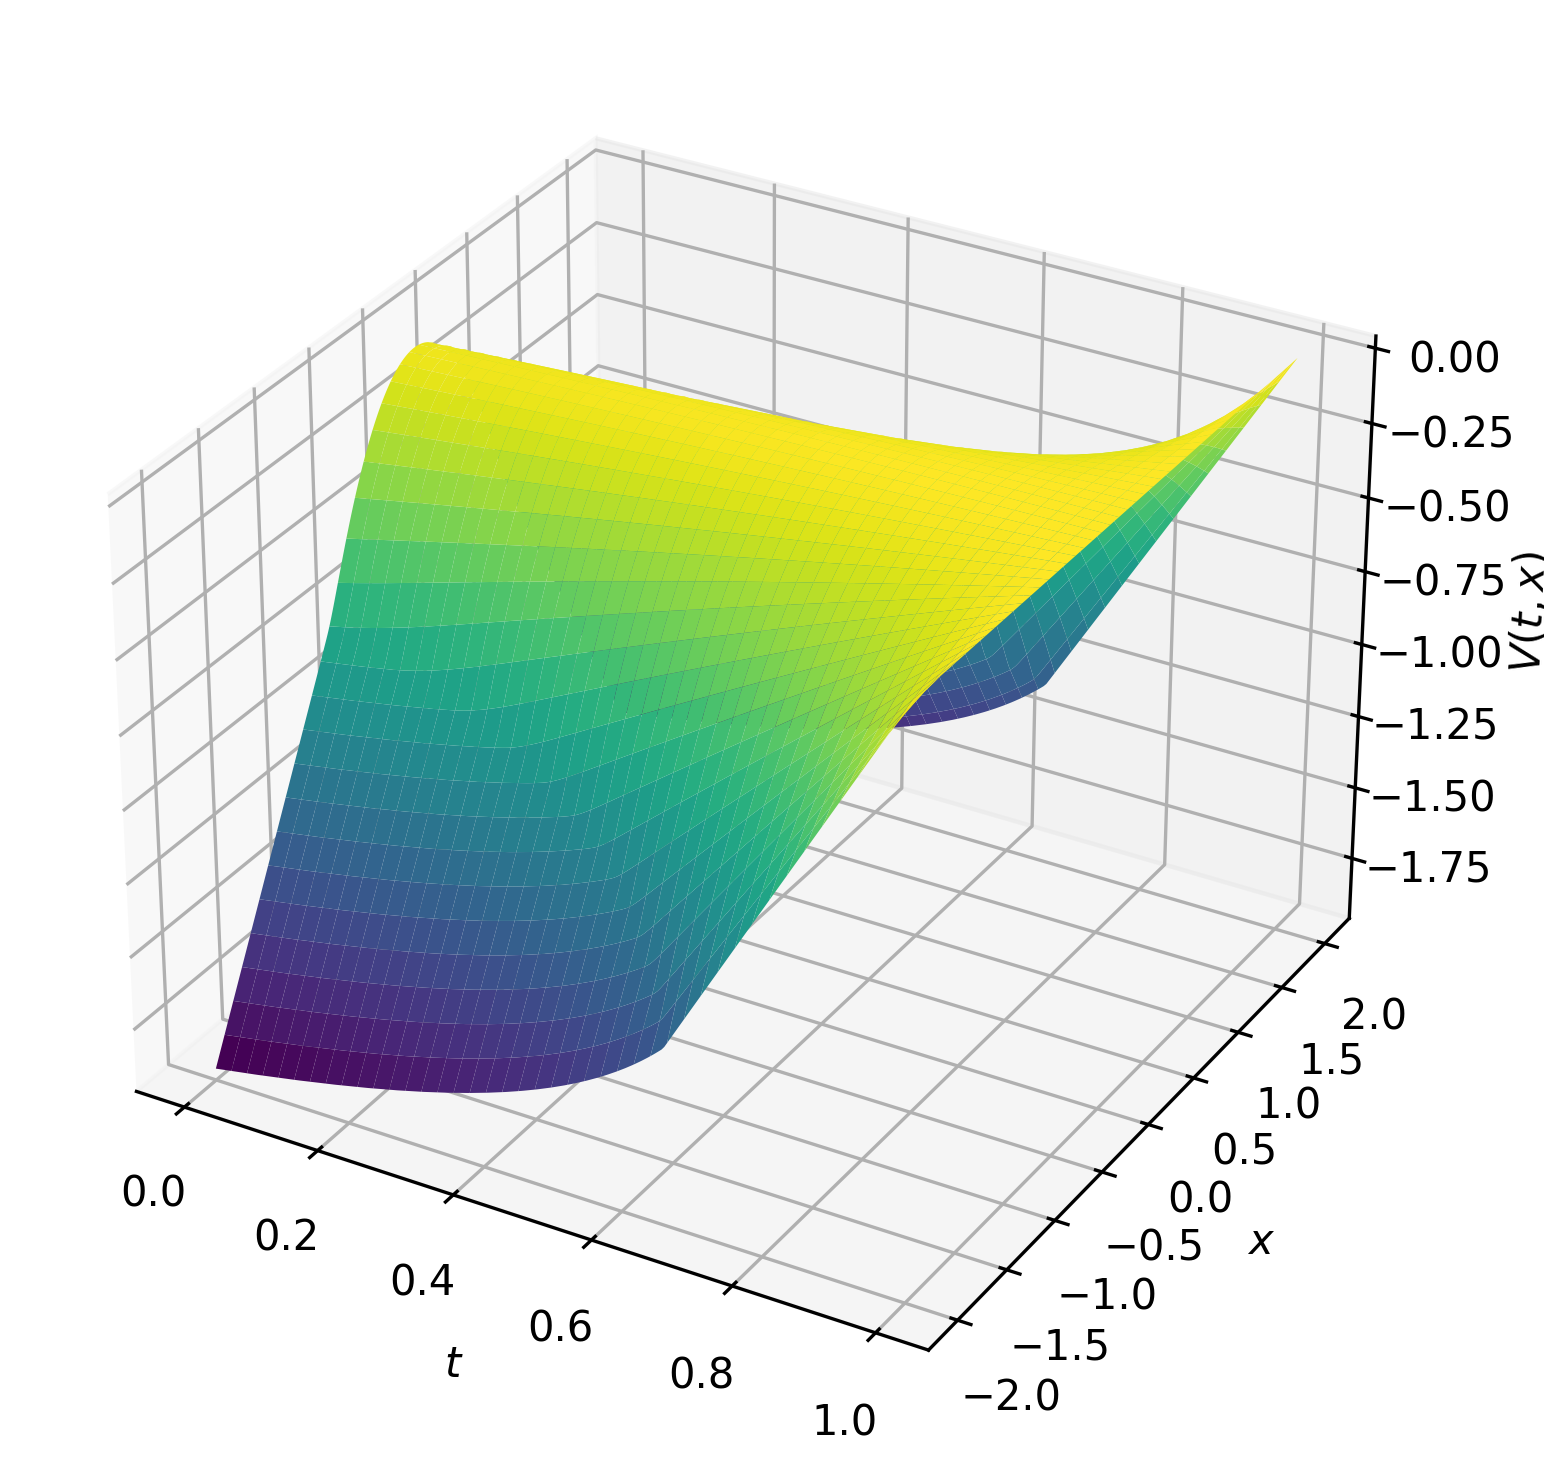

In [38]:
x_grid = res.x_grid
t_grid = np.linspace(0, common['T'], n_t+1)

v = res.values
T_meshgrid, X_meshgrid = np.meshgrid(t_grid, x_grid, indexing='ij')

fig = plt.figure(figsize=(8, 5), dpi=300)
ax = fig.add_subplot(projection='3d') 

surface = ax.plot_surface(T_meshgrid, X_meshgrid, v, cmap='viridis', linewidth=0, antialiased=True)

#ax.set_title('Numerical solution of FEX rate problem')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$x$')
ax.set_zlabel(r'$V(t,x)$')

fig.subplots_adjust(right=5)
plt.tight_layout()
plt.show()

# 2. DDQN model

## 2.1 Training

In [11]:
train_x_min = -3.0
train_x_max = 3.0
target_min = -3.0
target_max = 3.0
min_abs_impulse = 0.05

In [12]:
ratio = 1
M = 1024
n_B = int(ratio * M) #batch size 

episodes = 1000000

DDQN_FEX_params = DDQN.FEXParameters(
    mu=common['mu'],
    sigma=common['sigma'],
    w=common['w_const'],
    m=common['m'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],

    n_t=n_t,
    n_zeta=n_zeta,

    train_x_min=train_x_min,
    train_x_max=train_x_max,

    target_min=target_min,
    target_max=target_max,

    min_abs_impulse=min_abs_impulse,
    distance_reduction_tol=1e-6,
)

DDQN_config = DDQN.TrainConfiguration(
    seed=42,

    episodes=episodes,
    n_B=n_B,
    lr=2e-4,
    weight_decay=0.0,
    grad_clip_norm=10.0,

    M=M,
    buffer_capacity=1000000,
    warmup_transitions=65536,

    target_update_interval=500,
    tau=1.0,

    epsilon_start=0.8,
    epsilon_end=0.08,
    epsilon_decay_episodes=int(0.3*episodes),

    tail_sample_prob=0.3,
    tail_std=1.25,
    eval_interval_sample_prob=0.45,

    hidden_dims=(512, 64),
    activation_str='relu',

    silu_gain=1.0,
    output_gain=0.1,
    zero_bias=True,

    loss='huber',
    huber_delta=1.0,

    target_chunk_size=64,
    state_chunk_size=4096,

    log_every=100000,
    checkpoint_path='./DDQN models/DDQN_model_25_04_2026.pt',
)

model_DDQN, history_DDQN = DDQN.train(DDQN_FEX_params, DDQN_config)


Episode:       1/1000000 | lr=0.0002 | Loss=nan | Mean reward=-1.35755e+00 | Temporal difference (abs)=nan | Mean Q-value=nan | Mean target=nan | Epsilon=0.8000 | Replay buffer size=1024
Episode:  100000/1000000 | lr=0.0002 | Loss=1.30308e-05 | Mean reward=-3.98865e-02 | Temporal difference (abs)=1.54899e-03 | Mean Q-value=-5.00874e-02 | Mean target=-4.91498e-02 | Epsilon=0.5600 | Replay buffer size=1000000
Episode:  200000/1000000 | lr=0.0002 | Loss=2.51616e-05 | Mean reward=-3.99706e-02 | Temporal difference (abs)=1.79948e-03 | Mean Q-value=-5.49482e-02 | Mean target=-5.58057e-02 | Epsilon=0.3200 | Replay buffer size=1000000
Episode:  300000/1000000 | lr=0.0002 | Loss=2.74415e-05 | Mean reward=-2.23074e-02 | Temporal difference (abs)=2.93870e-03 | Mean Q-value=-6.63050e-02 | Mean target=-6.75578e-02 | Epsilon=0.0800 | Replay buffer size=1000000
Episode:  400000/1000000 | lr=0.0002 | Loss=2.32171e-05 | Mean reward=-2.71607e-02 | Temporal difference (abs)=2.82020e-03 | Mean Q-value=-9.

## 2.2 Evaluation and comparison against explicit-impulse scheme

In [13]:
policy = DDQN.policy_curve(model=model_DDQN, x_grid=x_grid, time_index=0, state_chunk_size=DDQN_config.state_chunk_size)
MC_policy = DDQN.MC_policy_curve(model=model_DDQN, x_grid=x_grid, n_paths_per_x=512, batch_x=32, path_batch_size=2048, antithetic=True, seed=123)

In [14]:
print(f'Scheme: v(0,m)={float(np.interp(common['m'], x_grid, v_m_0))}')
print(f'DDQN: V(0,m;theta)={float(np.interp(common['m'], MC_policy['x'], MC_policy['value']))}')

Scheme: v(0,m)=-0.05214544082368151
DDQN: V(0,m;theta)=-0.052052414930345015


### 2.2.1 Policy evaluation

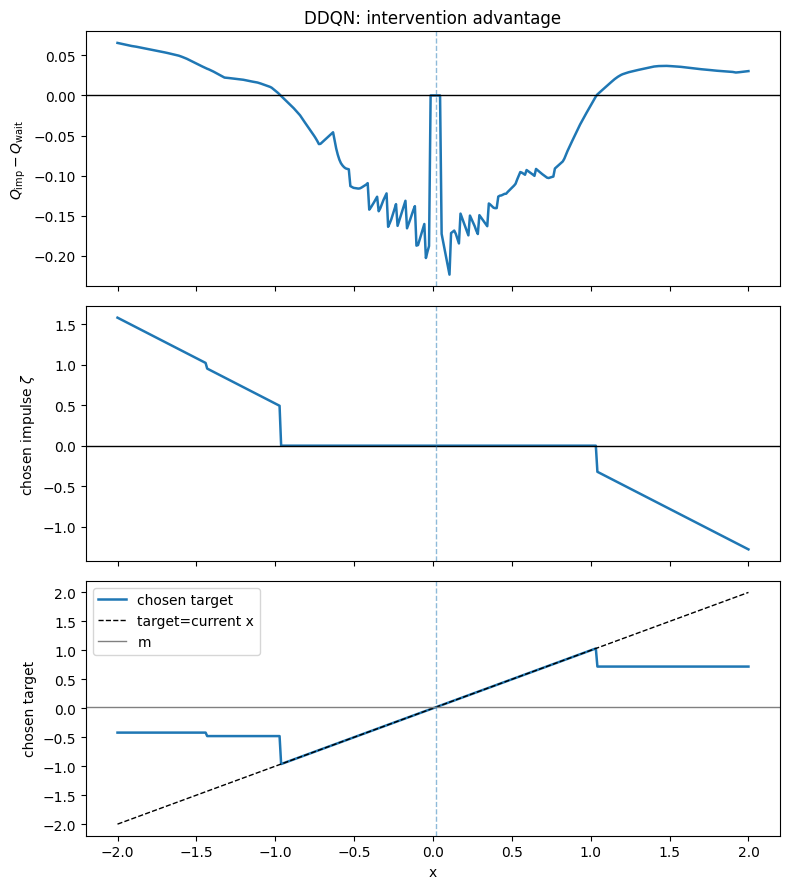

In [15]:
#plotting policy learnt by DDQN
fig, axs = plt.subplots(3, 1, figsize=(8.0, 9.0), sharex=True)

# intervention advantage = best impulse value - wait value
axs[0].plot(x_grid, policy['advantage'], linewidth=1.8)
axs[0].axhline(0.0, color='black', linewidth=1.0)
axs[0].set_ylabel(r'$Q_{\rm imp}-Q_{\rm wait}$')
axs[0].set_title('DDQN: intervention advantage')

# chosen impulse zeta
axs[1].plot(x_grid, policy['zeta'], linewidth=1.8)
axs[1].axhline(0.0, color='black', linewidth=1.0)
axs[1].set_ylabel(r'chosen impulse $\zeta$')

# chosen post-intervention target
axs[2].plot(x_grid, policy['target'], linewidth=1.8, label='chosen target')
axs[2].plot(x_grid, x_grid, '--', color='black', linewidth=1.0, label='target=current x')

axs[2].axhline(common['m'], color='gray', linewidth=1.0, label='m')
for ax in axs:
    ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.5)

axs[2].set_ylabel('chosen target')
axs[2].set_xlabel('x')
axs[2].legend()

fig.tight_layout()
plt.show()

### 2.2.2 Training history

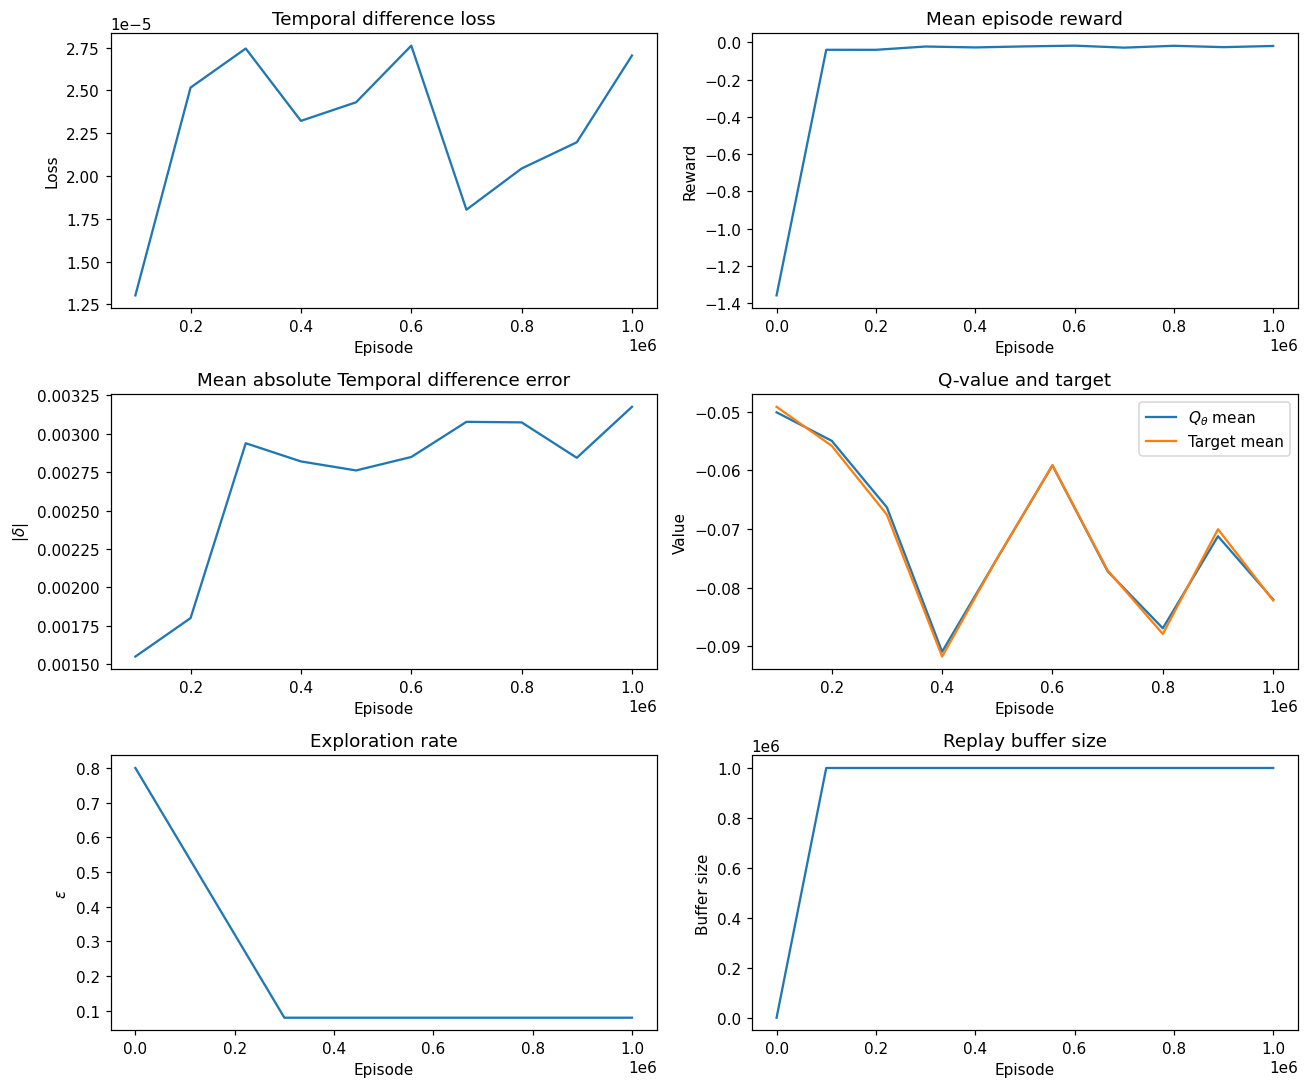

In [16]:
df = pd.DataFrame(history_DDQN).copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['episode']).sort_values('episode')
x = df['episode']

#plotting
fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=110)
axes = axes.ravel()

axes[0].plot(x, df['loss'])
axes[0].set_title('Temporal difference loss')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Loss')

axes[1].plot(x, df['reward_mean'])
axes[1].set_title('Mean episode reward')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')

axes[2].plot(x, df['td_abs'])
axes[2].set_title('Mean absolute Temporal difference error')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel(r'$|\delta|$')

axes[3].plot(x, df['q_mean'], label=r'$Q_\theta$ mean')
axes[3].plot(x, df['target_mean'], label='Target mean')
axes[3].set_title('Q-value and target')
axes[3].set_xlabel('Episode')
axes[3].set_ylabel('Value')
axes[3].legend()

axes[4].plot(x, df['epsilon'])
axes[4].set_title('Exploration rate')
axes[4].set_xlabel('Episode')
axes[4].set_ylabel(r'$\epsilon$')

axes[5].plot(x, df['buffer_size'])
axes[5].set_title('Replay buffer size')
axes[5].set_xlabel('Episode')
axes[5].set_ylabel('Buffer size')

plt.tight_layout()
plt.show()

### 2.2.3 Plots

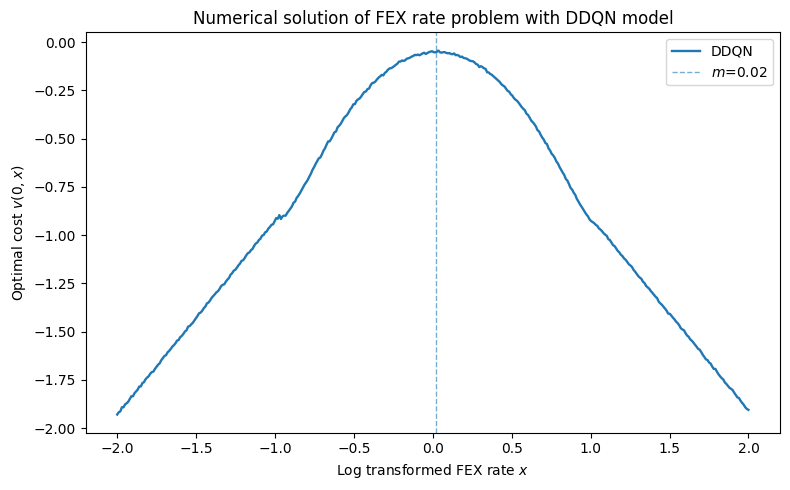

In [ ]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))

#DDQN plot + 95% confidence interval
ax.plot(MC_policy['x'], MC_policy['value'], linewidth=1.7, label='DDQN')
#ax.fill_between(MC_policy['x'], MC_policy['value'] - 1.96*MC_policy['std'], MC_policy['value'] + 1.96*MC_policy['std'], alpha=0.12, label=r'$\pm 2\,\mathrm{SE}$')

#m=0.02
ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.6, label=rf'$m$={common['m']}')

ax.set_ylabel(r'Optimal cost $v(0,x)$')
ax.set_xlabel(r'$x$')
ax.set_title('Numerical solution of FEX rate problem with DDQN model')
ax.legend()
fig.tight_layout()
plt.show()


In [18]:
x_grid_full = res.x_grid
t_grid_full = np.linspace(0.0, common['T'], n_t + 1)

time_stride = 8
x_stride = 4

time_idx_plot = np.arange(0, n_t + 1, time_stride)
if time_idx_plot[-1] != n_t:
    time_idx_plot = np.append(time_idx_plot, n_t)

x_idx_plot = np.arange(0, len(x_grid_full), x_stride)
if x_idx_plot[-1] != len(x_grid_full) - 1:
    x_idx_plot = np.append(x_idx_plot, len(x_grid_full) - 1)

t_grid_plot = t_grid_full[time_idx_plot]
x_grid_plot = x_grid_full[x_idx_plot]

V_explicit_plot = res.values[np.ix_(time_idx_plot, x_idx_plot)]

print('Number of time points:', len(t_grid_plot))
print('Number of x points:', len(x_grid_plot))
print('Surface shape:', V_explicit_plot.shape)

Number of time points: 33
Number of x points: 102
Surface shape: (33, 102)


In [19]:
n_paths_surface = 512
batch_x_surface = 64
path_batch_size_surface = 8192

V_mc_plot = np.zeros((len(time_idx_plot), len(x_grid_plot)), dtype=float)
SE_mc_plot = np.zeros((len(time_idx_plot), len(x_grid_plot)), dtype=float)

for k, time_index in enumerate(time_idx_plot):
    if int(time_index) >= n_t:
        V_mc_plot[k, :] = 0.0
        SE_mc_plot[k, :] = 0.0
        continue

    mc_t = DDQN.MC_policy_curve(
        model=model_DDQN,
        x_grid=x_grid_plot,
        time_index=int(time_index),
        n_paths_per_x=n_paths_surface,
        batch_x=batch_x_surface,
        path_batch_size=path_batch_size_surface,
        antithetic=True,
        seed=123 + int(time_index),
    )

    V_mc_plot[k, :] = mc_t['value']
    SE_mc_plot[k, :] = mc_t['std']

    print(f'{k + 1:>3d}/{len(time_idx_plot)} | time_index={int(time_index):>4d} | t={t_grid_full[int(time_index)]:.4f}')

  1/33 | time_index=   0 | t=0.0000
  2/33 | time_index=   8 | t=0.0317
  3/33 | time_index=  16 | t=0.0635
  4/33 | time_index=  24 | t=0.0952
  5/33 | time_index=  32 | t=0.1270
  6/33 | time_index=  40 | t=0.1587
  7/33 | time_index=  48 | t=0.1905
  8/33 | time_index=  56 | t=0.2222
  9/33 | time_index=  64 | t=0.2540
 10/33 | time_index=  72 | t=0.2857
 11/33 | time_index=  80 | t=0.3175
 12/33 | time_index=  88 | t=0.3492
 13/33 | time_index=  96 | t=0.3810
 14/33 | time_index= 104 | t=0.4127
 15/33 | time_index= 112 | t=0.4444
 16/33 | time_index= 120 | t=0.4762
 17/33 | time_index= 128 | t=0.5079
 18/33 | time_index= 136 | t=0.5397
 19/33 | time_index= 144 | t=0.5714
 20/33 | time_index= 152 | t=0.6032
 21/33 | time_index= 160 | t=0.6349
 22/33 | time_index= 168 | t=0.6667
 23/33 | time_index= 176 | t=0.6984
 24/33 | time_index= 184 | t=0.7302
 25/33 | time_index= 192 | t=0.7619
 26/33 | time_index= 200 | t=0.7937
 27/33 | time_index= 208 | t=0.8254
 28/33 | time_index= 216 | t

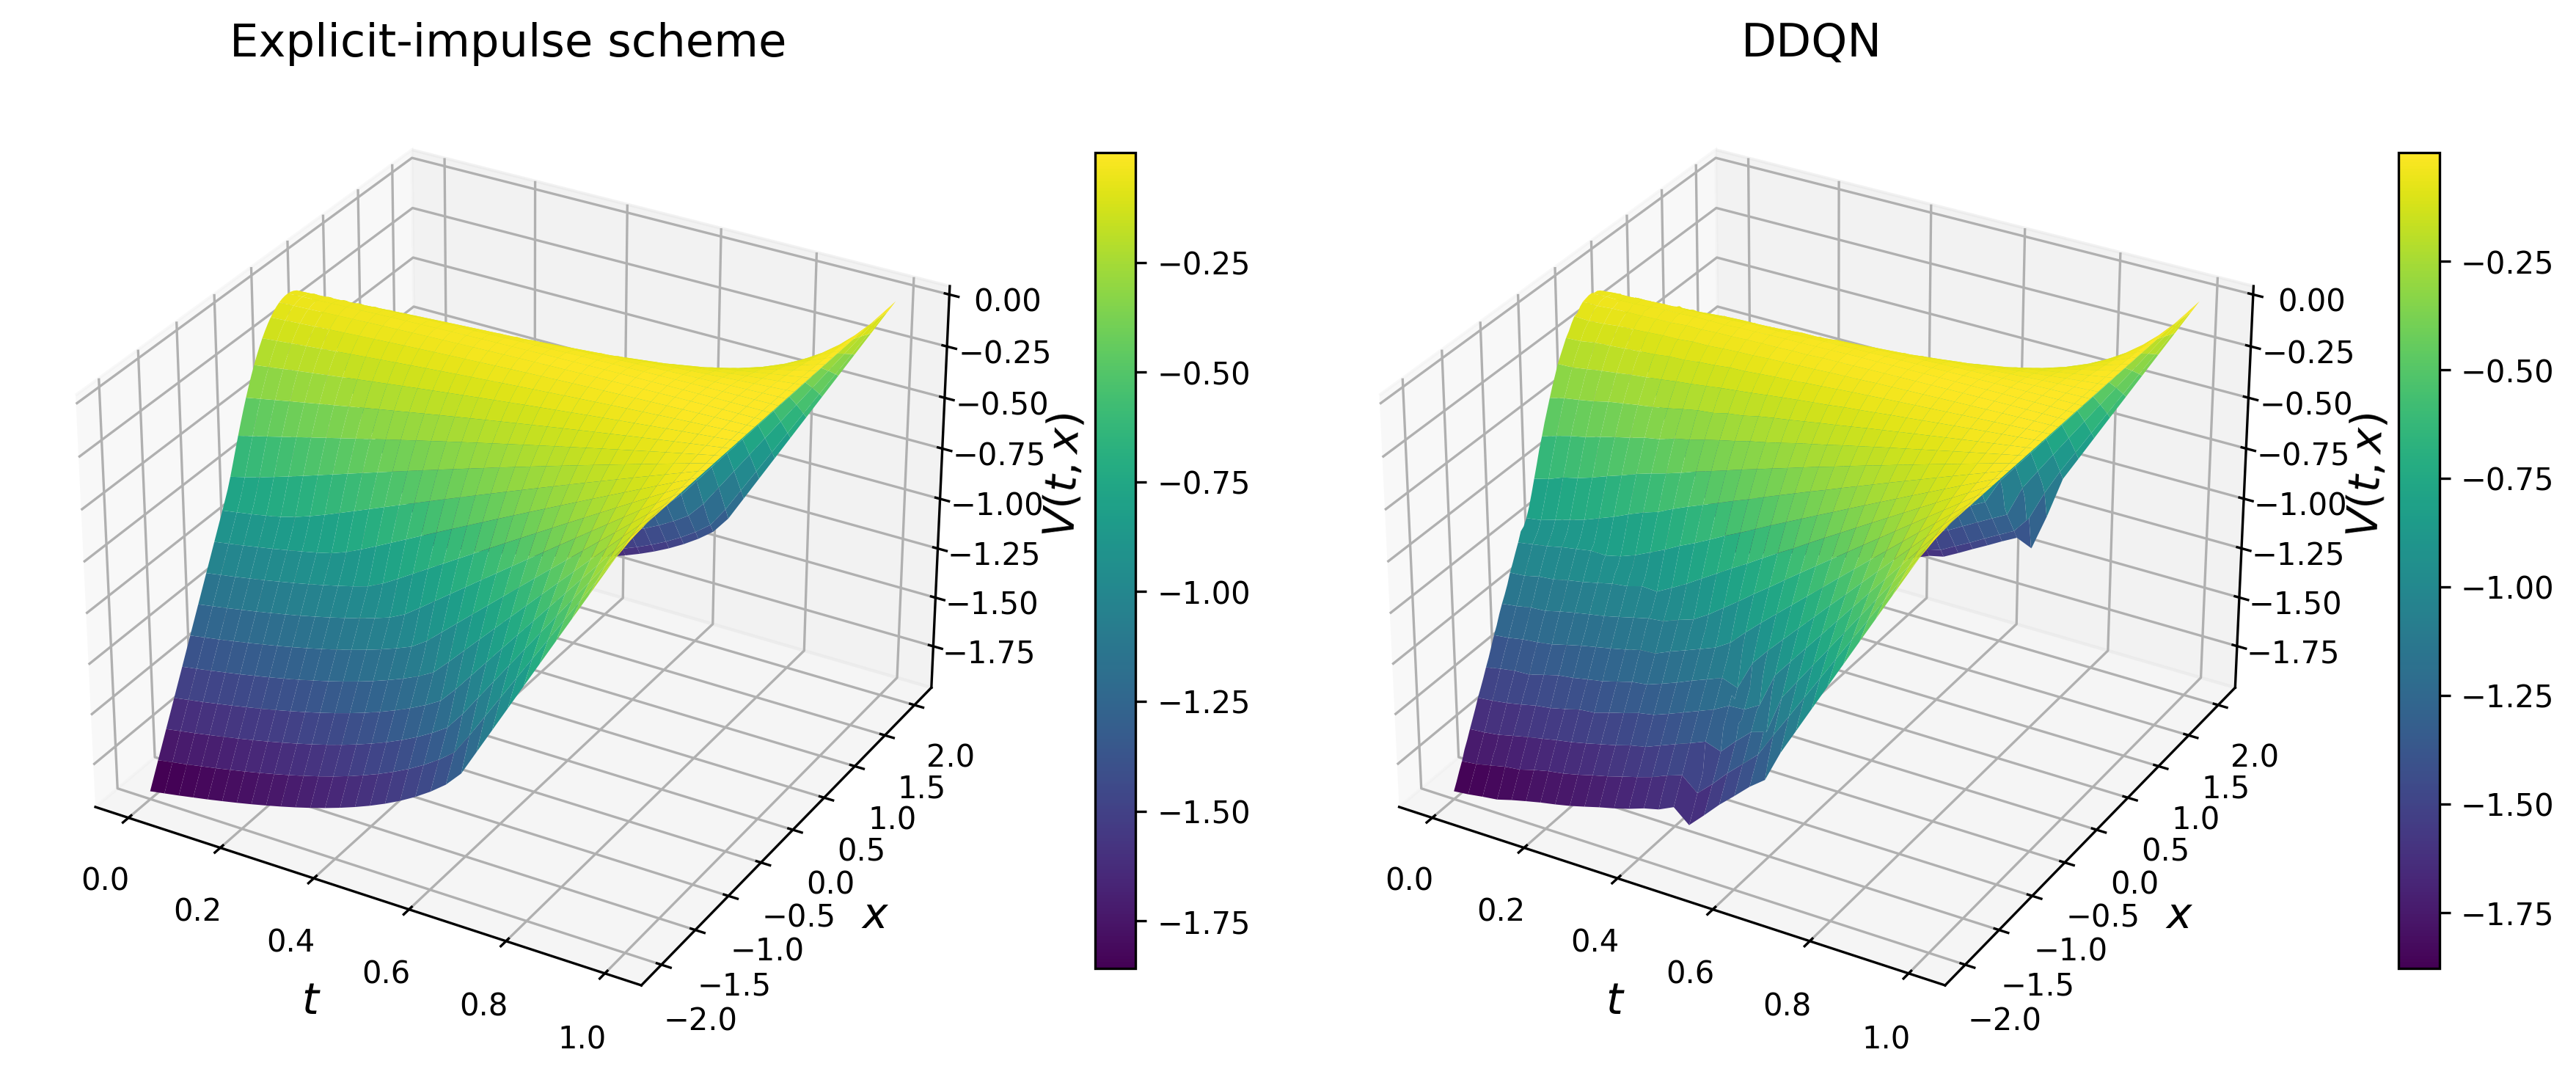

In [40]:
T_meshgrid_plot, X_meshgrid_plot = np.meshgrid(
    t_grid_plot,
    x_grid_plot,
    indexing='ij',
)

fig = plt.figure(figsize=(12, 6), dpi=300)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(
    T_meshgrid_plot,
    X_meshgrid_plot,
    V_explicit_plot,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax1.set_title('Explicit-impulse scheme', fontsize=15)
ax1.set_xlabel(r'$t$', fontsize=14)
ax1.set_ylabel(r'$x$', fontsize=14)
ax1.set_zlabel(r'$V(t,x)$', fontsize=14)
fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.08)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(
    T_meshgrid_plot,
    X_meshgrid_plot,
    V_mc_plot,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax2.set_title('DDQN', fontsize=15)
ax2.set_xlabel(r'$t$', fontsize=14)
ax2.set_ylabel(r'$x$', fontsize=14)
ax2.set_zlabel(r'$V(t,x)$', fontsize=14)
fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.08)

plt.tight_layout()
plt.show()

### 2.2.4 Comparison plots

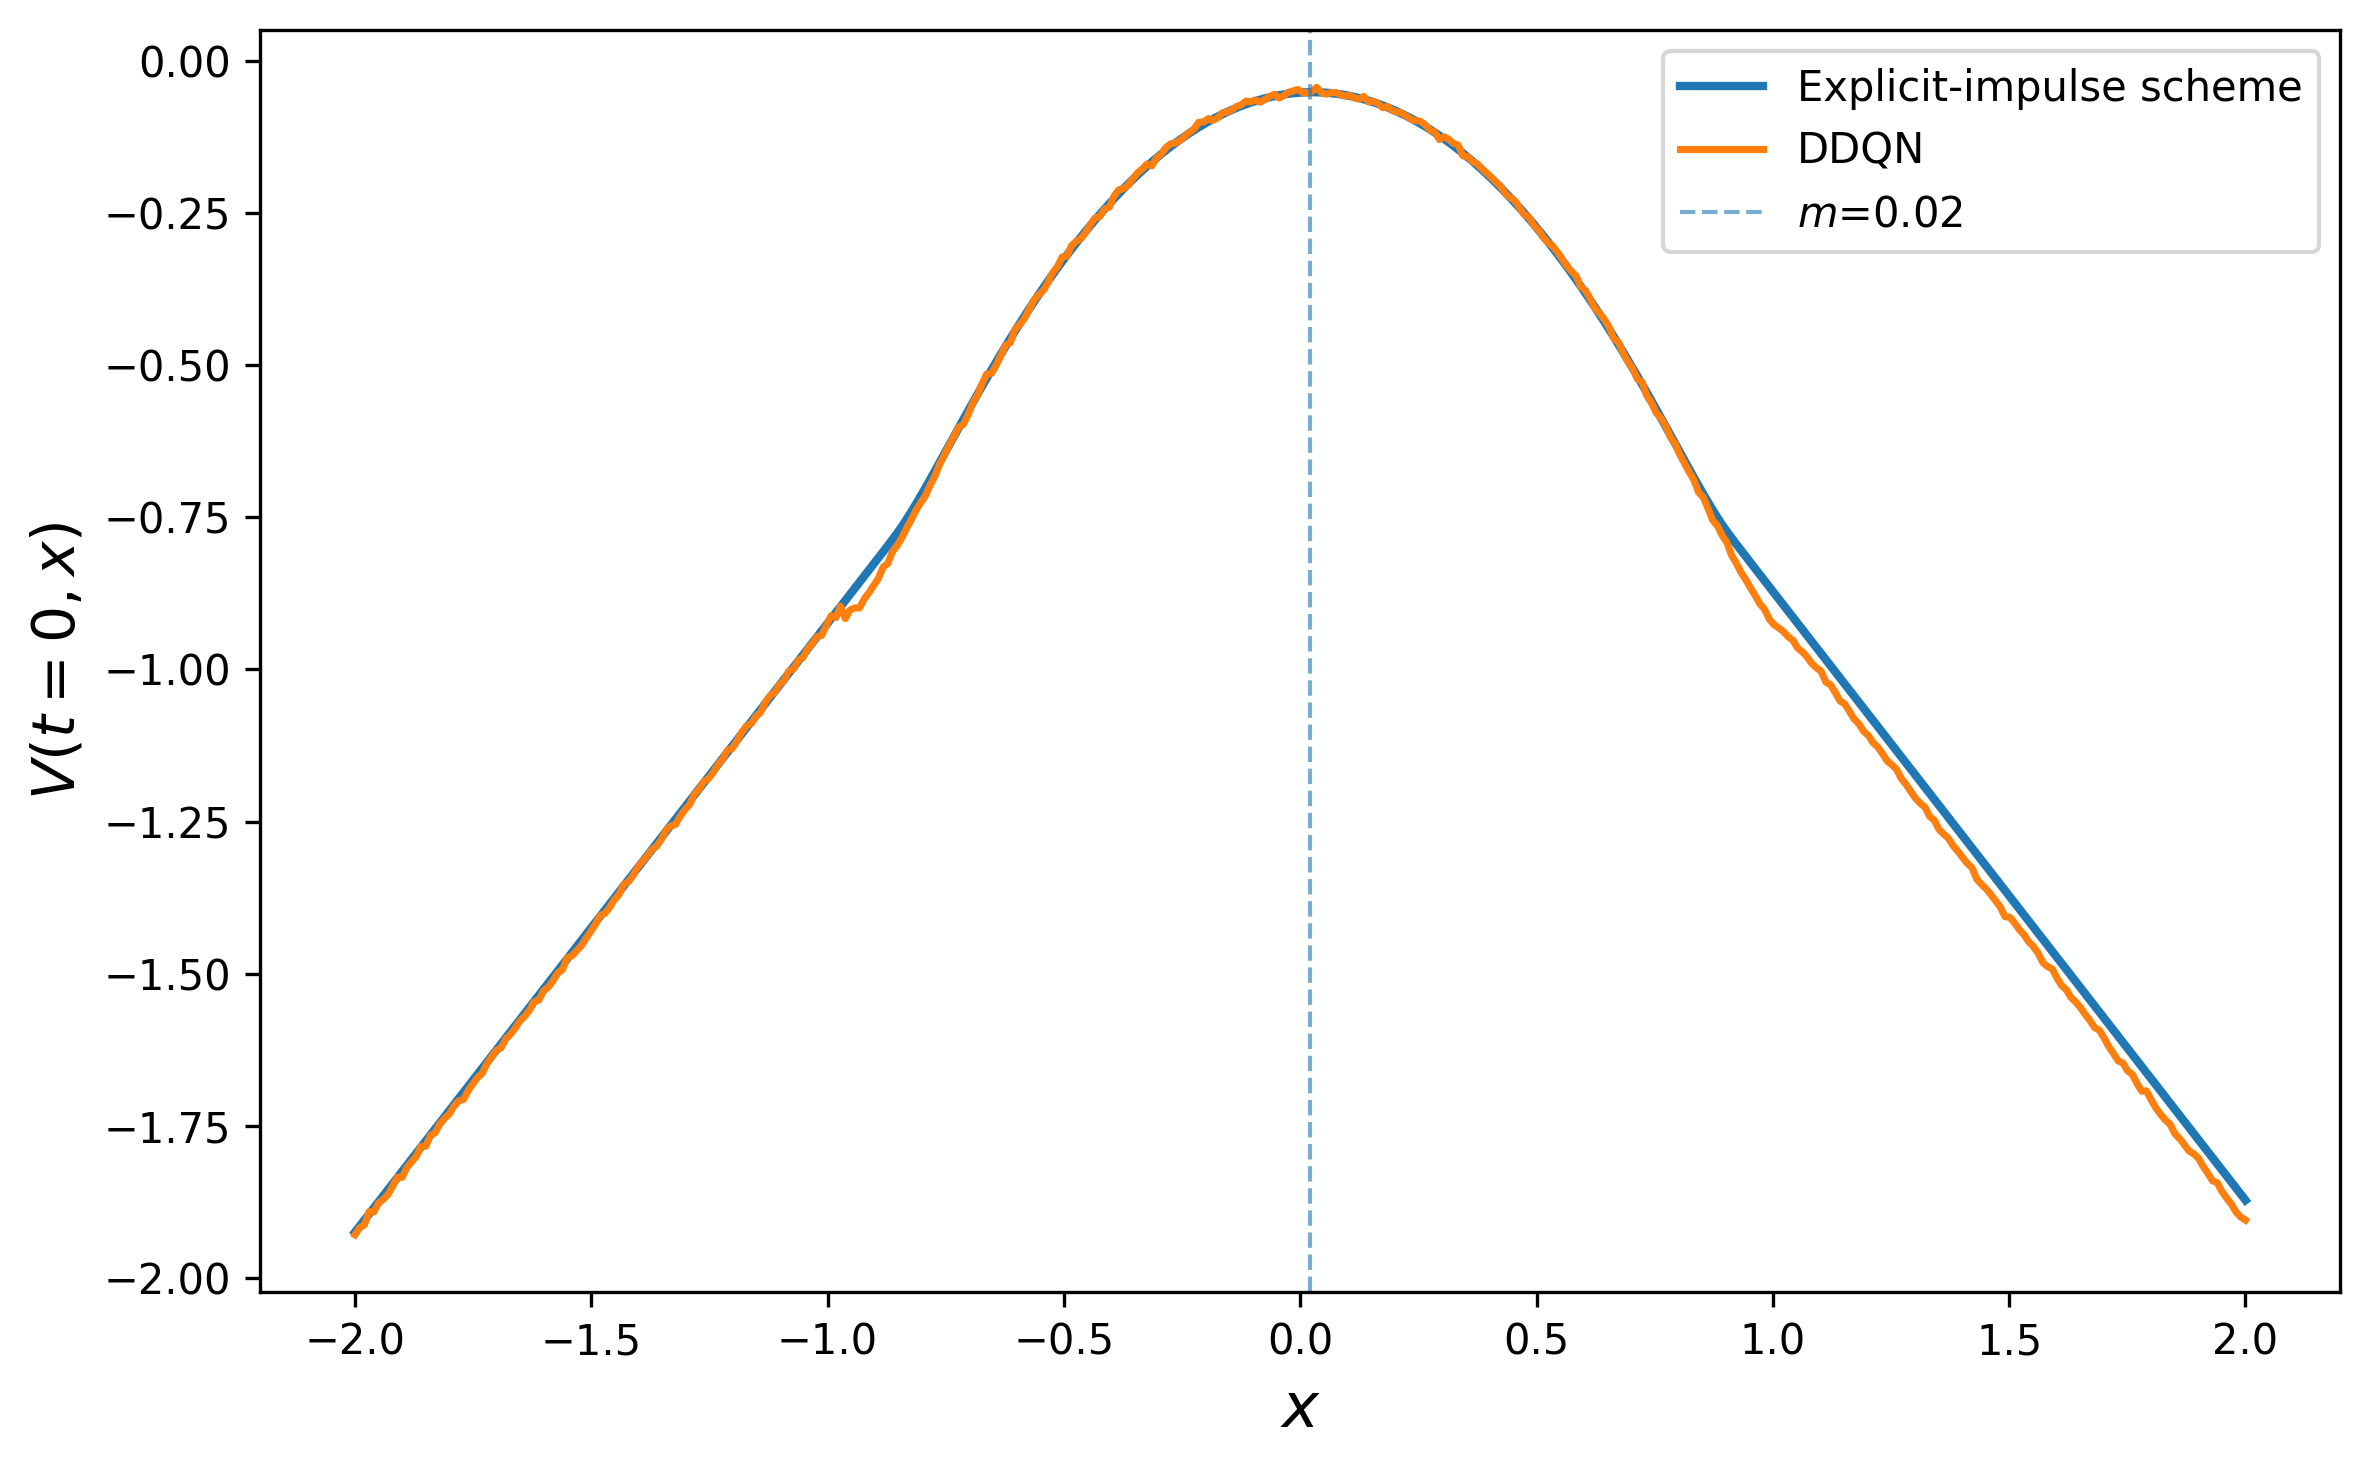

In [ ]:
#1D
fig, ax = plt.subplots(figsize=(8,5), dpi=300)

#Scheme
ax.plot(x_grid, v_m_0, linewidth=2.0, label='Explicit-impulse scheme')

#DDQN plot
ax.plot(MC_policy['x'], MC_policy['value'], linewidth=1.7, label='DDQN')
#ax.fill_between(MC_policy['x'], MC_policy['value'] - 1.96*MC_policy['std'], MC_policy['value'] + 1.96*MC_policy['std'], alpha=0.12, label=r'$\pm 2\,\mathrm{SE}$')

#m=0.02
ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.6, label=rf'$m$={common['m']}')

ax.set_xlabel(r'$x$', fontsize=15)
ax.set_ylabel(r'$V(t=0,x)$', fontsize=14)
#ax.set_title(r'Comparison of DDQN and Explicit-impulse scheme value functions', fontsize=14)
ax.legend()
fig.tight_layout()
plt.show()


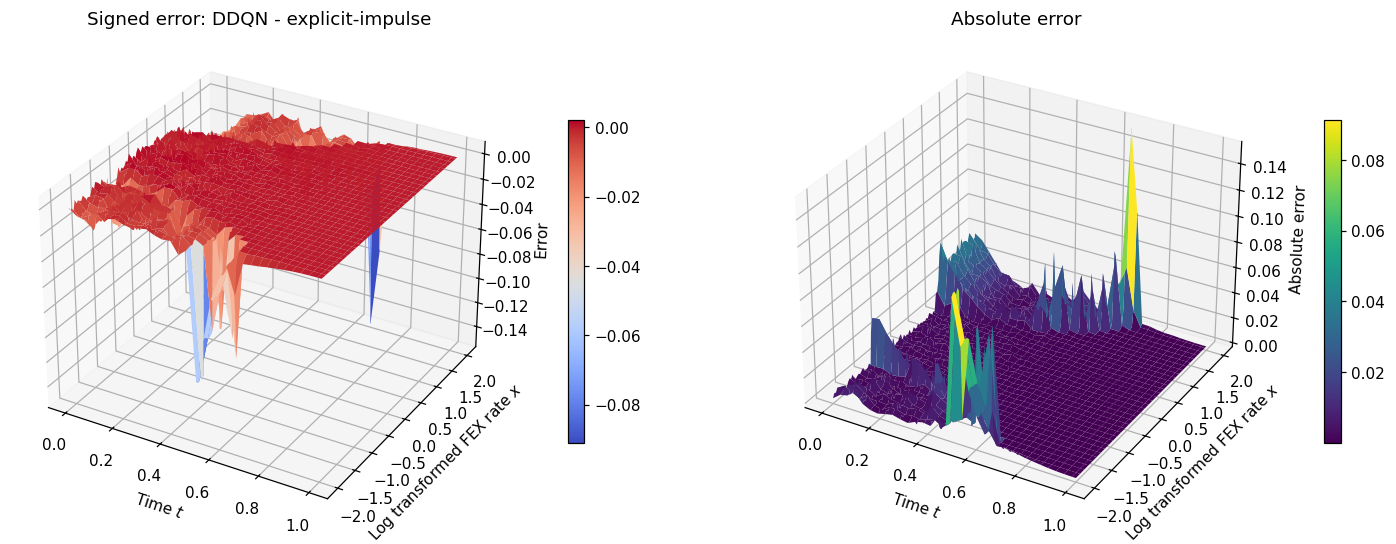

In [ ]:
signed_error_plot = V_mc_plot - V_explicit_plot
abs_error_plot = np.abs(signed_error_plot)

fig = plt.figure(figsize=(14, 5), dpi=110)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(
    T_meshgrid_plot,
    X_meshgrid_plot,
    signed_error_plot,
    cmap='coolwarm',
    linewidth=0,
    antialiased=True,
)
ax1.set_title('Signed error: DDQN - explicit-impulse')
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_zlabel('Error')
fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.08)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(
    T_meshgrid_plot,
    X_meshgrid_plot,
    abs_error_plot,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax2.set_title('Absolute error')
ax2.set_xlabel('$t$')
ax2.set_ylabel('$x$')
ax2.set_zlabel('Absolute error')
fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.08)

plt.tight_layout()
plt.show()

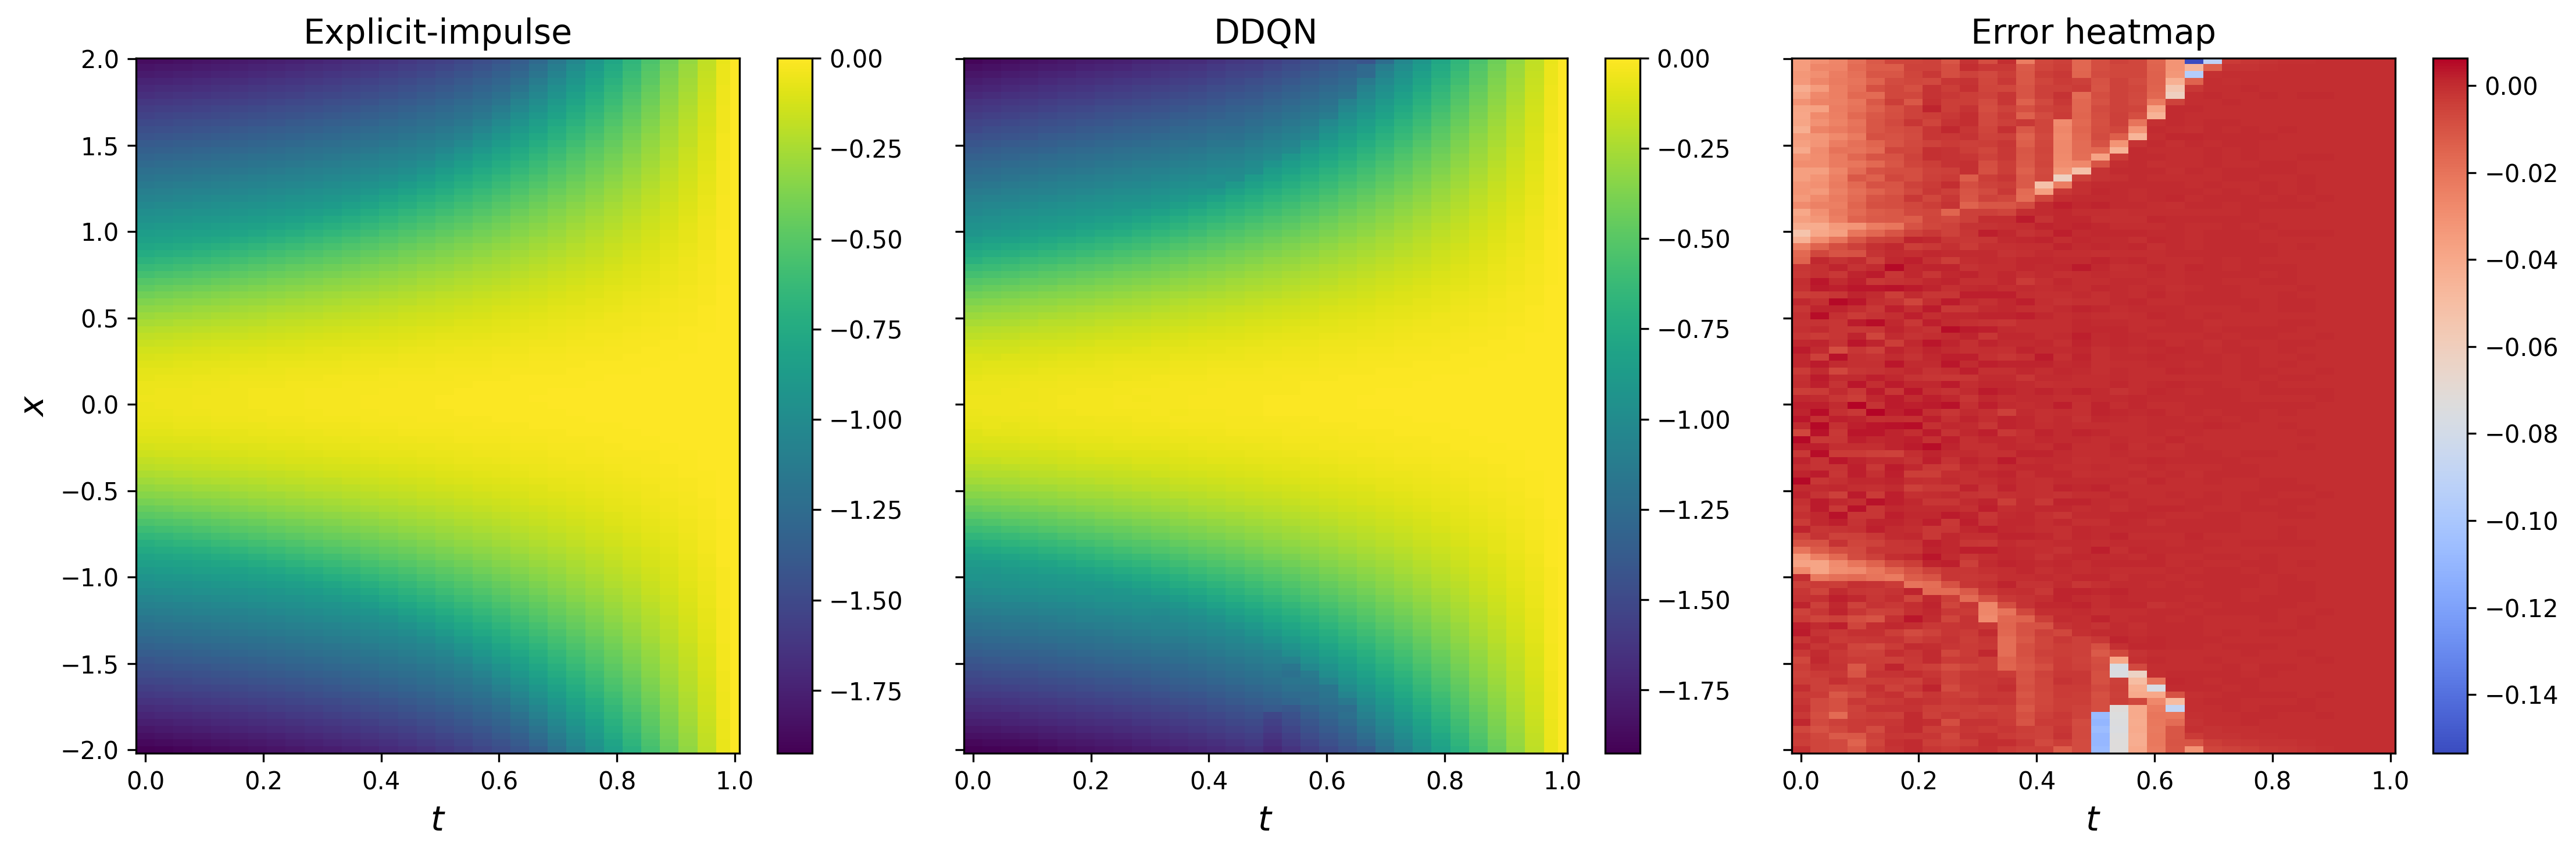

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=300, sharey=True)

im0 = axs[0].pcolormesh(
    t_grid_plot,
    x_grid_plot,
    V_explicit_plot.T,
    shading='auto',
    cmap='viridis',
)
axs[0].set_title('Explicit-impulse', fontsize=14)
axs[0].set_xlabel('$t$', fontsize=14)
axs[0].set_ylabel('$x$', fontsize=14)
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].pcolormesh(
    t_grid_plot,
    x_grid_plot,
    V_mc_plot.T,
    shading='auto',
    cmap='viridis',
)
axs[1].set_title('DDQN', fontsize=14)
axs[1].set_xlabel('$t$', fontsize=14)
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].pcolormesh(
    t_grid_plot,
    x_grid_plot,
    signed_error_plot.T,
    shading='auto',
    cmap='coolwarm',
)
axs[2].set_title('Error heatmap', fontsize=14)
axs[2].set_xlabel('$t$', fontsize=14)
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

# 3. PPO-SIL model

In [24]:
PPO_SIL_config = PPO_SIL.make_default_config(
    mu=common['mu'],
    sigma=common['sigma'],
    w=common['w_const'],
    m=common['m'],
    beta=common['beta'],
    gamma=common['gamma'],
    kappa=common['kappa'],
    c=common['c'],
    T=common['T'],

    n_t=n_t,                   
    n_zeta=n_zeta,

    x_init_min=-3.0,
    x_init_max=3.0,
    x_scale=1.0,
    use_clustered_target_grid=True,
    target_cluster_intensity=10.0,

    device=DEVICE,
    
    rollout_envs=1024,
    eval_envs=4096,
    train_iters=300,
    ppo_epochs=5,
    minibatch_size=8192,
    clip_eps=0.3,
    value_coef=0.5,
    entropy_coef=1e-3,
    gae_lambda=1.0,
    max_grad_norm=1.0,
    lr=2e-4,
    target_kl=0.01,
    sil_policy_coef=0.05,
    sil_value_coef=0.05,
    sil_updates_per_iter=1,
    sil_warmup_iters=1,
    sil_margin=0.02,
    save_dir='./PPO models/',
    trunk_layers=3,
    hidden_dim=512
)

## 3.1 Training

In [25]:
result = PPO_SIL.train(PPO_SIL_config)
print(PPO_SIL.evaluate_policy(result['actor_critic'], result['env']))

[iter 0001/300] train=-48.2779 eval=-2.9965 pi=-0.0028 v= 322.0315 sil_pi= 0.0000 sil_v= 0.0000 ent= 1.6924 intv= 0.2692 |w|= 0.0500
[iter 0010/300] train=-3.6574 eval=-2.9792 pi=-0.0020 v= 0.5332 sil_pi= 0.1964 sil_v= 0.1939 ent= 0.1946 intv= 0.0288 |w|= 0.0500
[iter 0020/300] train=-1.6512 eval=-1.7263 pi=-0.0003 v= 0.0076 sil_pi= 0.0560 sil_v= 0.0209 ent= 0.0208 intv= 0.0032 |w|= 0.0500
[iter 0030/300] train=-1.4253 eval=-1.4292 pi=-0.0002 v= 0.0054 sil_pi= 0.0472 sil_v= 0.0158 ent= 0.0057 intv= 0.0030 |w|= 0.0500
[iter 0040/300] train=-1.3787 eval=-1.3994 pi=-0.0003 v= 0.0034 sil_pi= 0.0147 sil_v= 0.0047 ent= 0.0062 intv= 0.0029 |w|= 0.0500
[iter 0050/300] train=-1.3783 eval=-1.4112 pi=-0.0002 v= 0.0036 sil_pi= 0.0062 sil_v= 0.0090 ent= 0.0017 intv= 0.0029 |w|= 0.0500
[iter 0060/300] train=-1.3618 eval=-1.4024 pi= 0.0002 v= 0.0042 sil_pi= 0.0087 sil_v= 0.0116 ent= 0.0017 intv= 0.0028 |w|= 0.0500
[iter 0070/300] train=-1.4001 eval=-1.4166 pi=-0.0001 v= 0.0041 sil_pi= 0.0077 sil_v= 0

## 3.2 Evaluation and comparison against explicit-impulse scheme

In [26]:
@torch.no_grad()
def PPO_SIL_policy_curve(actor_critic, env, x_grid, time_index=0):
    """Deterministic PPO-SIL policy diagnostics on an x-grid at a fixed time index."""
    was_training = actor_critic.training
    actor_critic.eval()

    x_np = np.asarray(x_grid, dtype=np.float32).reshape(-1)
    x = torch.as_tensor(x_np, device=env.device, dtype=env.dtype)
    t_idx = torch.full((x.numel(),), int(time_index), device=env.device, dtype=torch.long)
    obs = env.observe(x, t_idx)

    intervene_logits, target_logits, critic_value = actor_critic.dist_and_value(obs)
    p_intervene = torch.sigmoid(intervene_logits)
    intervene = intervene_logits > 0.0
    target_idx = torch.argmax(target_logits, dim=-1)
    raw_target = env.target_grid[target_idx]
    raw_jump = raw_target - x

    chosen_target = torch.where(intervene, raw_target, x)
    chosen_jump = torch.where(intervene, raw_jump, torch.zeros_like(raw_jump))
    w = actor_critic.fixed_w(obs)

    if was_training:
        actor_critic.train()

    return {
        'x': x_np,
        'p_intervene': p_intervene.detach().cpu().numpy(),
        'intervene': intervene.detach().cpu().numpy().astype(bool),
        'target_idx': target_idx.detach().cpu().numpy(),
        'raw_target': raw_target.detach().cpu().numpy(),
        'raw_jump': raw_jump.detach().cpu().numpy(),
        'target': chosen_target.detach().cpu().numpy(),
        'zeta': chosen_jump.detach().cpu().numpy(),
        'w': w.detach().cpu().numpy(),
        'critic_value': critic_value.detach().cpu().numpy(),
    }


@torch.no_grad()
def PPO_SIL_make_antithetic_noise(rows, cols, env, antithetic=True):
    """Noise matrix with optional antithetic pairing, matching the PPO-SIL environment dtype/device."""
    rows = int(rows)
    cols = int(cols)
    if antithetic and cols >= 2 and cols % 2 == 0:
        half = torch.randn((rows, cols // 2), device=env.device, dtype=env.dtype)
        return torch.cat((half, -half), dim=1)
    return torch.randn((rows, cols), device=env.device, dtype=env.dtype)


@torch.no_grad()
def PPO_SIL_fex_step(env, x, step_idx, intervene, target_idx, noise=None):
    """One PPO-SIL FEX step with explicit noise injection for common-random-number MC plots."""
    cfg = env.cfg
    x = x.to(device=env.device, dtype=env.dtype)
    step_idx = step_idx.to(device=env.device, dtype=torch.long)
    intervene = intervene.to(device=env.device).bool()
    target_idx = target_idx.to(device=env.device, dtype=torch.long)

    t = step_idx.to(env.dtype) * env.dt
    discount = torch.exp(-cfg.beta * t)
    w = torch.full_like(x, float(cfg.w))

    target = env.target_grid[target_idx]
    x_after_impulse = torch.where(intervene, target, x)
    jump = x_after_impulse - x

    impulse_cost = torch.where(
        intervene,
        cfg.kappa * jump.abs() + cfg.c,
        torch.zeros_like(x),
    )
    running_cost = ((x_after_impulse - cfg.m).pow(2) + cfg.gamma * w.pow(2)) * env.dt
    reward = -discount * (running_cost + impulse_cost)

    if noise is None:
        noise = torch.randn_like(x_after_impulse)
    else:
        noise = noise.to(device=env.device, dtype=env.dtype)

    next_x = x_after_impulse - cfg.mu * w * env.dt + cfg.sigma * env.sqrt_dt * noise
    next_x = next_x.clamp(cfg.x_init_min, cfg.x_init_max)
    return next_x, reward


@torch.no_grad()
def PPO_SIL_MC_policy_curve(
    actor_critic,
    env,
    x_grid,
    n_paths_per_x=512,
    time_index=0,
    batch_x=32,
    path_batch_size=8192,
    deterministic=True,
    antithetic=True,
    seed=None,
):
    """Monte Carlo value curve for the deterministic PPO-SIL policy from a fixed time index."""
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))

    was_training = actor_critic.training
    actor_critic.eval()

    x_np = np.asarray(x_grid, dtype=np.float32).reshape(-1)
    n_x = x_np.size
    n_paths = int(n_paths_per_x)
    start_time = int(time_index)

    values = np.zeros(n_x, dtype=float)
    stds = np.zeros(n_x, dtype=float)

    if start_time >= int(env.cfg.n_t):
        if was_training:
            actor_critic.train()
        return {'x': x_np, 'value': values, 'std': stds}

    batch_x = max(1, int(batch_x))
    path_batch_size = max(1, int(path_batch_size))

    for outer_start in range(0, n_x, batch_x):
        outer_stop = min(n_x, outer_start + batch_x)
        current_x_np = x_np[outer_start:outer_stop]
        rows = current_x_np.size
        x0 = torch.as_tensor(current_x_np, device=env.device, dtype=env.dtype)

        sum_v = torch.zeros(rows, device=env.device, dtype=env.dtype)
        sumsq_v = torch.zeros(rows, device=env.device, dtype=env.dtype)
        paths_done = 0

        while paths_done < n_paths:
            cols = min(n_paths - paths_done, max(1, path_batch_size // rows))
            if antithetic and cols > 1 and cols % 2 == 1:
                cols -= 1
            cols = max(1, cols)

            x = x0.view(rows, 1).repeat(1, cols).reshape(-1)
            total_reward = torch.zeros(rows * cols, device=env.device, dtype=env.dtype)

            for t in range(start_time, int(env.cfg.n_t)):
                t_idx = torch.full((rows * cols,), t, device=env.device, dtype=torch.long)
                obs = env.observe(x, t_idx)
                act = actor_critic.act(obs, deterministic=deterministic)
                noise = PPO_SIL_make_antithetic_noise(rows, cols, env, antithetic=antithetic).reshape(-1)
                x, reward = PPO_SIL_fex_step(
                    env=env,
                    x=x,
                    step_idx=t_idx,
                    intervene=act['intervene'],
                    target_idx=act['target_idx'],
                    noise=noise,
                )
                total_reward = total_reward + reward

            vals = total_reward.view(rows, cols)
            sum_v = sum_v + vals.sum(dim=1)
            sumsq_v = sumsq_v + vals.square().sum(dim=1)
            paths_done += cols

        mean = sum_v / n_paths
        if n_paths > 1:
            sample_var = torch.clamp((sumsq_v - sum_v.square() / n_paths) / (n_paths - 1), min=0.0)
            std = torch.sqrt(sample_var / n_paths)
        else:
            std = torch.zeros_like(mean)

        values[outer_start:outer_stop] = mean.detach().cpu().numpy()
        stds[outer_start:outer_stop] = std.detach().cpu().numpy()

    if was_training:
        actor_critic.train()

    return {'x': x_np, 'value': values, 'std': stds}

In [27]:
actor_critic_PPO = result['actor_critic']
env_PPO = result['env']

PPO_policy = PPO_SIL_policy_curve(
    actor_critic=actor_critic_PPO,
    env=env_PPO,
    x_grid=x_grid,
    time_index=0,
)
PPO_MC_policy = PPO_SIL_MC_policy_curve(
    actor_critic=actor_critic_PPO,
    env=env_PPO,
    x_grid=x_grid,
    n_paths_per_x=512,
    time_index=0,
    batch_x=32,
    path_batch_size=8192,
    deterministic=True,
    antithetic=True,
    seed=321,
)

print(f"Scheme: v(0,m)={float(np.interp(common['m'], np.linspace(-2,2,len(v_m_0)), v_m_0))}")
print(f"PPO-SIL: V(0,m;theta)={float(np.interp(common['m'], PPO_MC_policy['x'], PPO_MC_policy['value']))}")

Scheme: v(0,m)=-0.05214544082368151
PPO-SIL: V(0,m;theta)=-0.04995705253059373


### 3.2.1 Policy evaluation

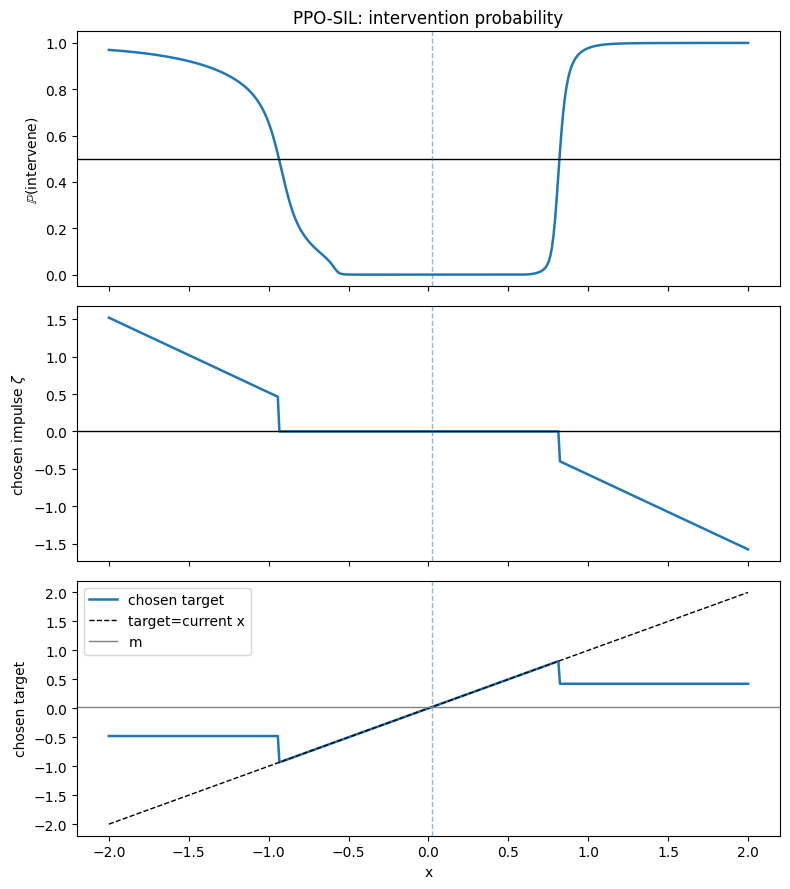

In [28]:
# plotting policy learnt by PPO-SIL
fig, axs = plt.subplots(3, 1, figsize=(8.0, 9.0), sharex=True)

# intervention probability replaces DDQN's intervention advantage diagnostic
axs[0].plot(x_grid, PPO_policy['p_intervene'], linewidth=1.8)
axs[0].axhline(0.5, color='black', linewidth=1.0)
axs[0].set_ylabel(r'$\mathbb{P}(\mathrm{intervene})$')
axs[0].set_title('PPO-SIL: intervention probability')

# chosen impulse zeta under deterministic policy
axs[1].plot(x_grid, PPO_policy['zeta'], linewidth=1.8)
axs[1].axhline(0.0, color='black', linewidth=1.0)
axs[1].set_ylabel(r'chosen impulse $\zeta$')

# chosen post-intervention target; if the policy waits, target is set to current x
axs[2].plot(x_grid, PPO_policy['target'], linewidth=1.8, label='chosen target')
axs[2].plot(x_grid, x_grid, '--', color='black', linewidth=1.0, label='target=current x')

axs[2].axhline(common['m'], color='gray', linewidth=1.0, label='m')
for ax in axs:
    ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.5)

axs[2].set_ylabel('chosen target')
axs[2].set_xlabel('x')
axs[2].legend()

fig.tight_layout()
plt.show()

### 3.2.2 Training history

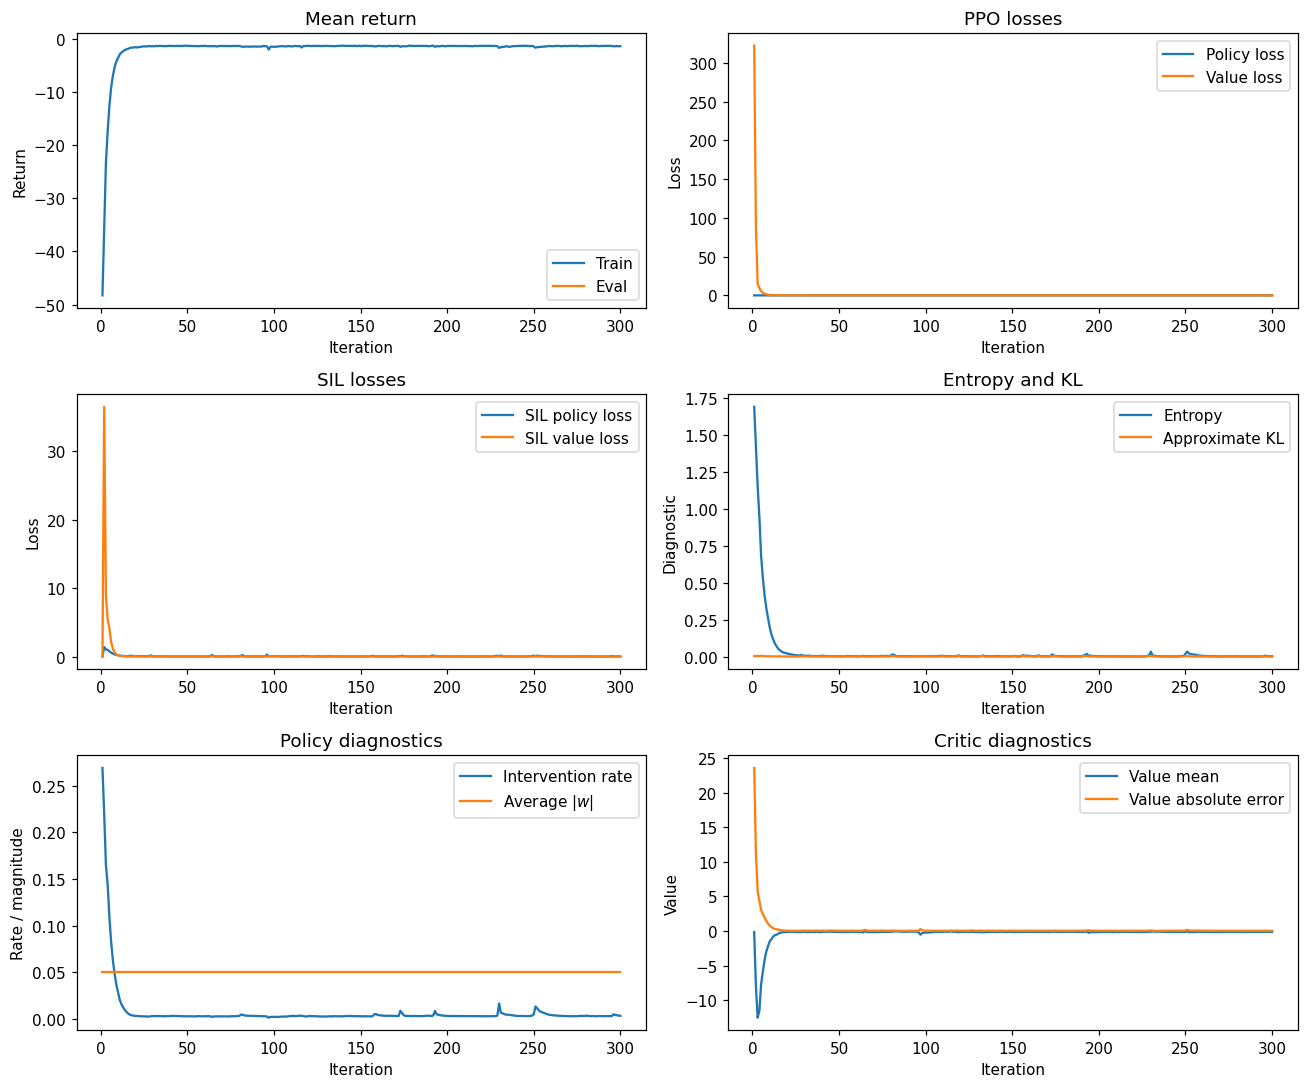

In [29]:
df_PPO = pd.DataFrame(result['history']).copy()

for col in df_PPO.columns:
    df_PPO[col] = pd.to_numeric(df_PPO[col], errors='coerce')

df_PPO = df_PPO.dropna(subset=['iter']).sort_values('iter')
x_PPO = df_PPO['iter'] + 1

# plotting
fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=110)
axes = axes.ravel()

axes[0].plot(x_PPO, df_PPO['train_return_mean'], label='Train')
axes[0].plot(x_PPO, df_PPO['eval_return_mean'], label='Eval')
axes[0].set_title('Mean return')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Return')
axes[0].legend()

axes[1].plot(x_PPO, df_PPO['policy_loss'], label='Policy loss')
axes[1].plot(x_PPO, df_PPO['value_loss'], label='Value loss')
axes[1].set_title('PPO losses')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].legend()

axes[2].plot(x_PPO, df_PPO['sil_policy_loss'], label='SIL policy loss')
axes[2].plot(x_PPO, df_PPO['sil_value_loss'], label='SIL value loss')
axes[2].set_title('SIL losses')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].legend()

axes[3].plot(x_PPO, df_PPO['entropy'], label='Entropy')
axes[3].plot(x_PPO, df_PPO['kl'], label='Approximate KL')
axes[3].set_title('Entropy and KL')
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel('Diagnostic')
axes[3].legend()

axes[4].plot(x_PPO, df_PPO['intervene_rate'], label='Intervention rate')
axes[4].plot(x_PPO, df_PPO['avg_abs_w'], label=r'Average $|w|$')
axes[4].set_title('Policy diagnostics')
axes[4].set_xlabel('Iteration')
axes[4].set_ylabel('Rate / magnitude')
axes[4].legend()

axes[5].plot(x_PPO, df_PPO['value_mean'], label='Value mean')
axes[5].plot(x_PPO, df_PPO['value_abs_error'], label='Value absolute error')
axes[5].set_title('Critic diagnostics')
axes[5].set_xlabel('Iteration')
axes[5].set_ylabel('Value')
axes[5].legend()

plt.tight_layout()
plt.show()

### 3.2.3 Plots

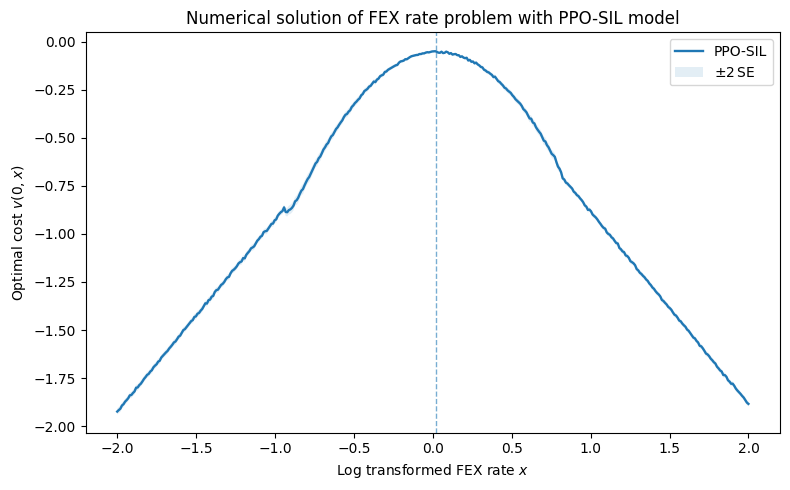

In [ ]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))

# PPO-SIL plot + 95% confidence interval
ax.plot(PPO_MC_policy['x'], PPO_MC_policy['value'], linewidth=1.7, label='PPO-SIL')
ax.fill_between(
    PPO_MC_policy['x'],
    PPO_MC_policy['value'] - 1.96 * PPO_MC_policy['std'],
    PPO_MC_policy['value'] + 1.96 * PPO_MC_policy['std'],
    alpha=0.12,
    label=r'$\pm 2\,\mathrm{SE}$',
)

# m=0.02
ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.6)

ax.set_ylabel(r'Optimal cost $v(0,x)$')
ax.set_xlabel(r'$x$')
ax.set_title('Numerical solution of FEX rate problem with PPO-SIL model')
ax.legend()
fig.tight_layout()
plt.show()

In [31]:
x_grid_full_PPO = res.x_grid
t_grid_full_PPO = res.t_grid
n_t_PPO = int(env_PPO.cfg.n_t)

if n_t_PPO != len(t_grid_full_PPO) - 1:
    raise ValueError('PPO-SIL and explicit-impulse grids use different n_t values; rebuild one of them before comparing surfaces.')

time_stride_PPO = 8
x_stride_PPO = 4

time_idx_plot_PPO = np.arange(0, n_t_PPO + 1, time_stride_PPO)
if time_idx_plot_PPO[-1] != n_t_PPO:
    time_idx_plot_PPO = np.append(time_idx_plot_PPO, n_t_PPO)

x_idx_plot_PPO = np.arange(0, len(x_grid_full_PPO), x_stride_PPO)
if x_idx_plot_PPO[-1] != len(x_grid_full_PPO) - 1:
    x_idx_plot_PPO = np.append(x_idx_plot_PPO, len(x_grid_full_PPO) - 1)

t_grid_plot_PPO = t_grid_full_PPO[time_idx_plot_PPO]
x_grid_plot_PPO = x_grid_full_PPO[x_idx_plot_PPO]

V_explicit_plot_PPO = res.values[np.ix_(time_idx_plot_PPO, x_idx_plot_PPO)]

print('Number of time points:', len(t_grid_plot_PPO))
print('Number of x points:', len(x_grid_plot_PPO))
print('Surface shape:', V_explicit_plot_PPO.shape)

Number of time points: 33
Number of x points: 102
Surface shape: (33, 102)


In [32]:
n_paths_surface_PPO = 512
batch_x_surface_PPO = 32
path_batch_size_surface_PPO = 8192

V_ppo_mc_plot = np.zeros((len(time_idx_plot_PPO), len(x_grid_plot_PPO)), dtype=float)
SE_ppo_mc_plot = np.zeros((len(time_idx_plot_PPO), len(x_grid_plot_PPO)), dtype=float)

for k, time_index in enumerate(time_idx_plot_PPO):
    if int(time_index) >= n_t_PPO:
        V_ppo_mc_plot[k, :] = 0.0
        SE_ppo_mc_plot[k, :] = 0.0
        continue

    mc_t = PPO_SIL_MC_policy_curve(
        actor_critic=actor_critic_PPO,
        env=env_PPO,
        x_grid=x_grid_plot_PPO,
        time_index=int(time_index),
        n_paths_per_x=n_paths_surface_PPO,
        batch_x=batch_x_surface_PPO,
        path_batch_size=path_batch_size_surface_PPO,
        deterministic=True,
        antithetic=True,
        seed=321 + int(time_index),
    )

    V_ppo_mc_plot[k, :] = mc_t['value']
    SE_ppo_mc_plot[k, :] = mc_t['std']

    print(f'{k + 1:>3d}/{len(time_idx_plot_PPO)} | time_index={int(time_index):>4d} | t={t_grid_full_PPO[int(time_index)]:.4f}')

  1/33 | time_index=   0 | t=0.0000
  2/33 | time_index=   8 | t=0.0317
  3/33 | time_index=  16 | t=0.0635
  4/33 | time_index=  24 | t=0.0952
  5/33 | time_index=  32 | t=0.1270
  6/33 | time_index=  40 | t=0.1587
  7/33 | time_index=  48 | t=0.1905
  8/33 | time_index=  56 | t=0.2222
  9/33 | time_index=  64 | t=0.2540
 10/33 | time_index=  72 | t=0.2857
 11/33 | time_index=  80 | t=0.3175
 12/33 | time_index=  88 | t=0.3492
 13/33 | time_index=  96 | t=0.3810
 14/33 | time_index= 104 | t=0.4127
 15/33 | time_index= 112 | t=0.4444
 16/33 | time_index= 120 | t=0.4762
 17/33 | time_index= 128 | t=0.5079
 18/33 | time_index= 136 | t=0.5397
 19/33 | time_index= 144 | t=0.5714
 20/33 | time_index= 152 | t=0.6032
 21/33 | time_index= 160 | t=0.6349
 22/33 | time_index= 168 | t=0.6667
 23/33 | time_index= 176 | t=0.6984
 24/33 | time_index= 184 | t=0.7302
 25/33 | time_index= 192 | t=0.7619
 26/33 | time_index= 200 | t=0.7937
 27/33 | time_index= 208 | t=0.8254
 28/33 | time_index= 216 | t

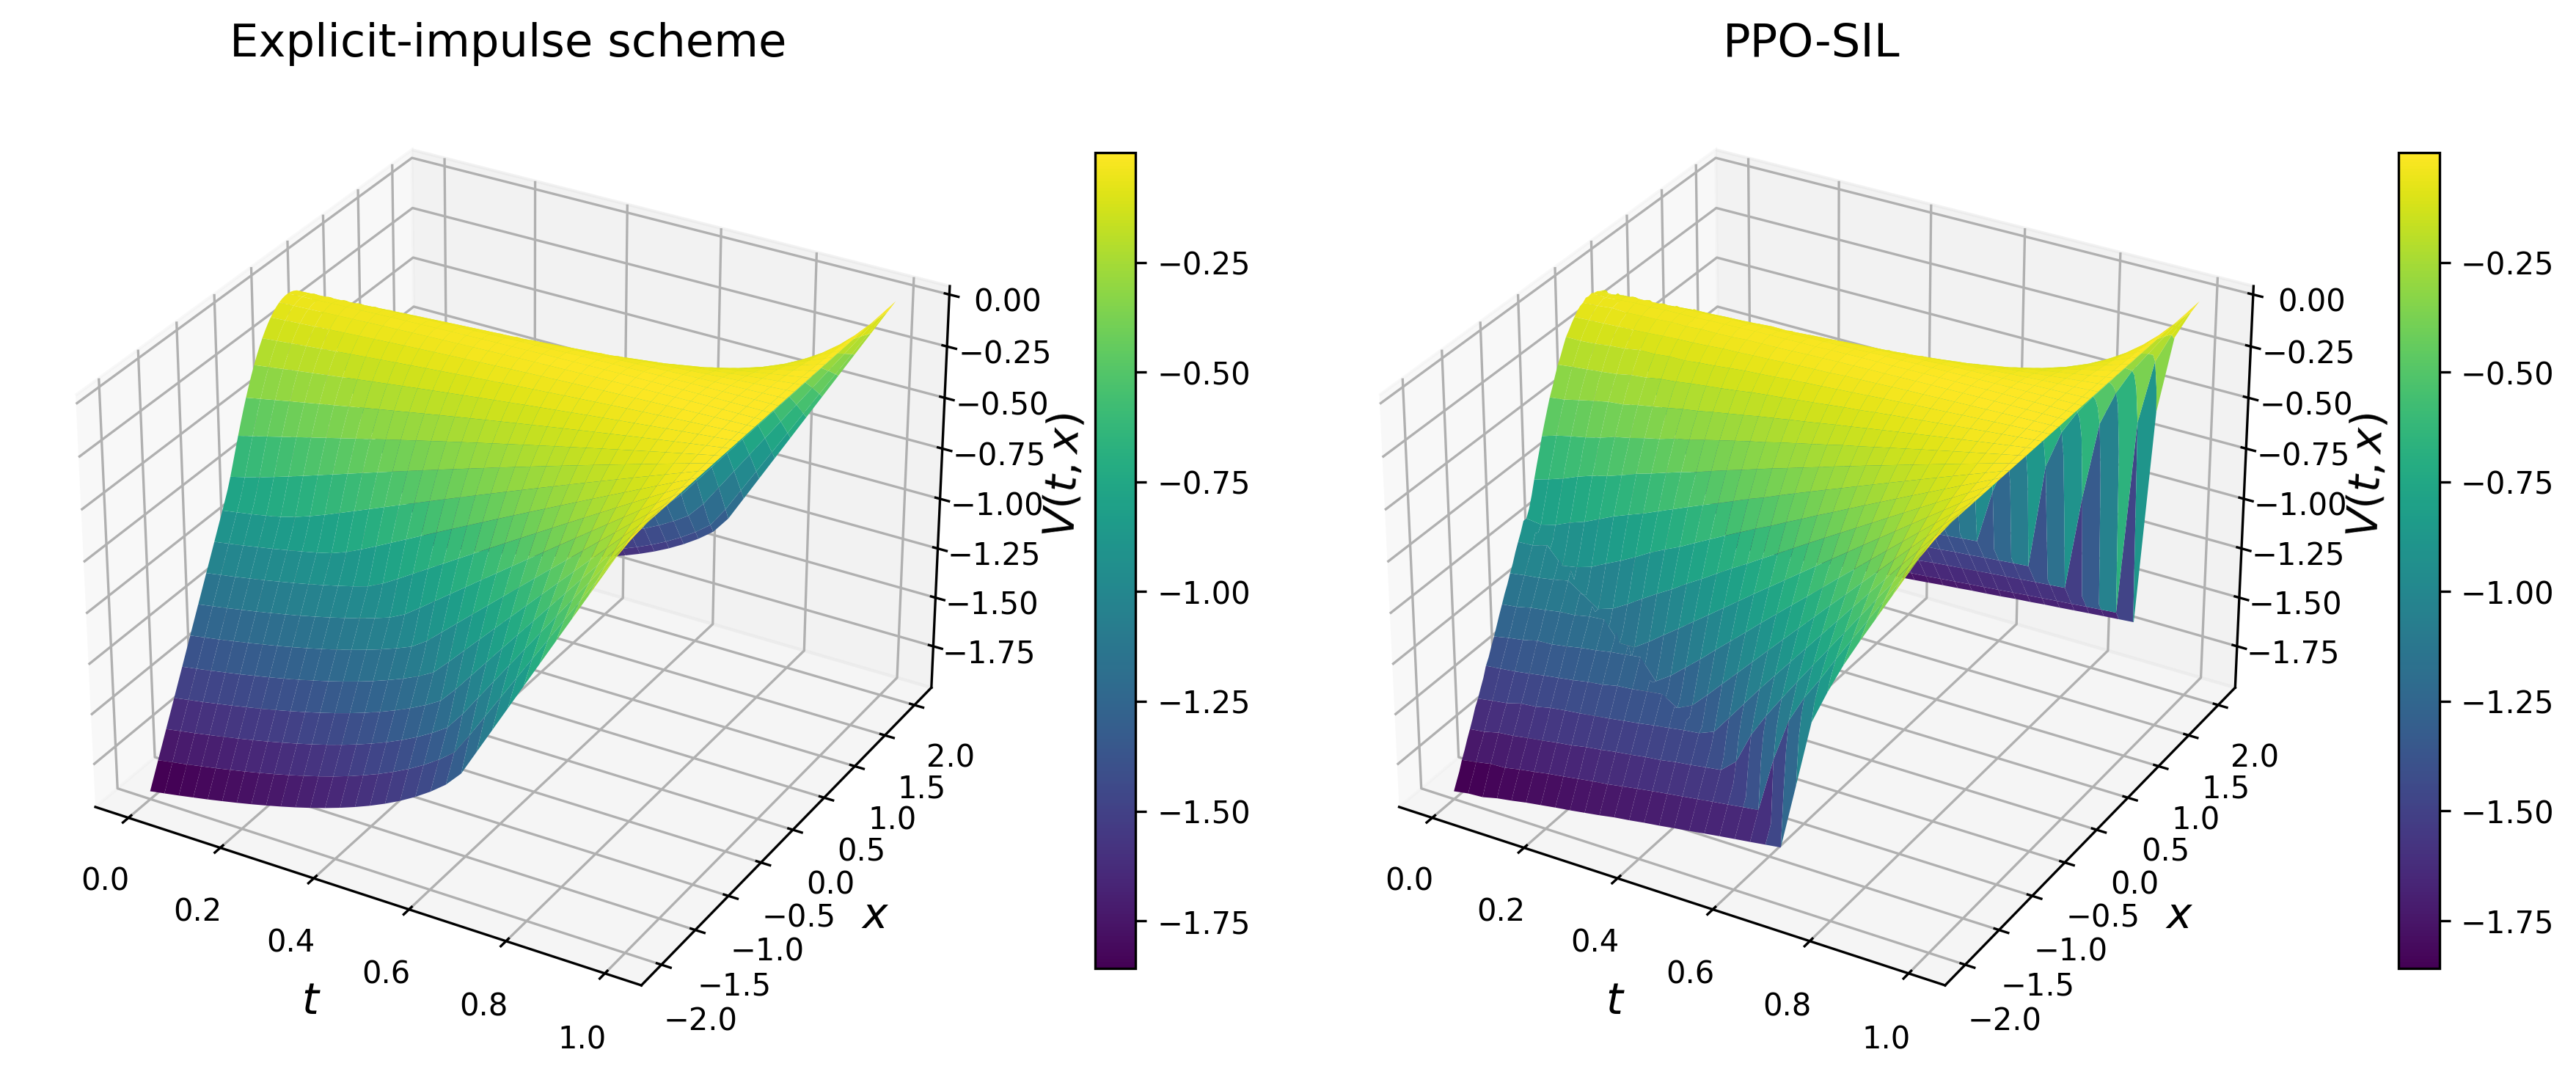

In [44]:
T_meshgrid_plot_PPO, X_meshgrid_plot_PPO = np.meshgrid(
    t_grid_plot_PPO,
    x_grid_plot_PPO,
    indexing='ij',
)

fig = plt.figure(figsize=(12, 6), dpi=300)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(
    T_meshgrid_plot_PPO,
    X_meshgrid_plot_PPO,
    V_explicit_plot_PPO,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax1.set_title('Explicit-impulse scheme', fontsize=15)
ax1.set_xlabel(r'$t$', fontsize=14)
ax1.set_ylabel(r'$x$', fontsize=14)
ax1.set_zlabel(r'$V(t,x)$', fontsize=14)
fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.08)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(
    T_meshgrid_plot_PPO,
    X_meshgrid_plot_PPO,
    V_ppo_mc_plot,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax2.set_title('PPO-SIL', fontsize=15)
ax2.set_xlabel(r'$t$', fontsize=14)
ax2.set_ylabel(r'$x$', fontsize=14)
ax2.set_zlabel(r'$V(t,x)$', fontsize=14)
fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.08)

plt.tight_layout()
plt.show()

### 3.2.4 Comparison plots

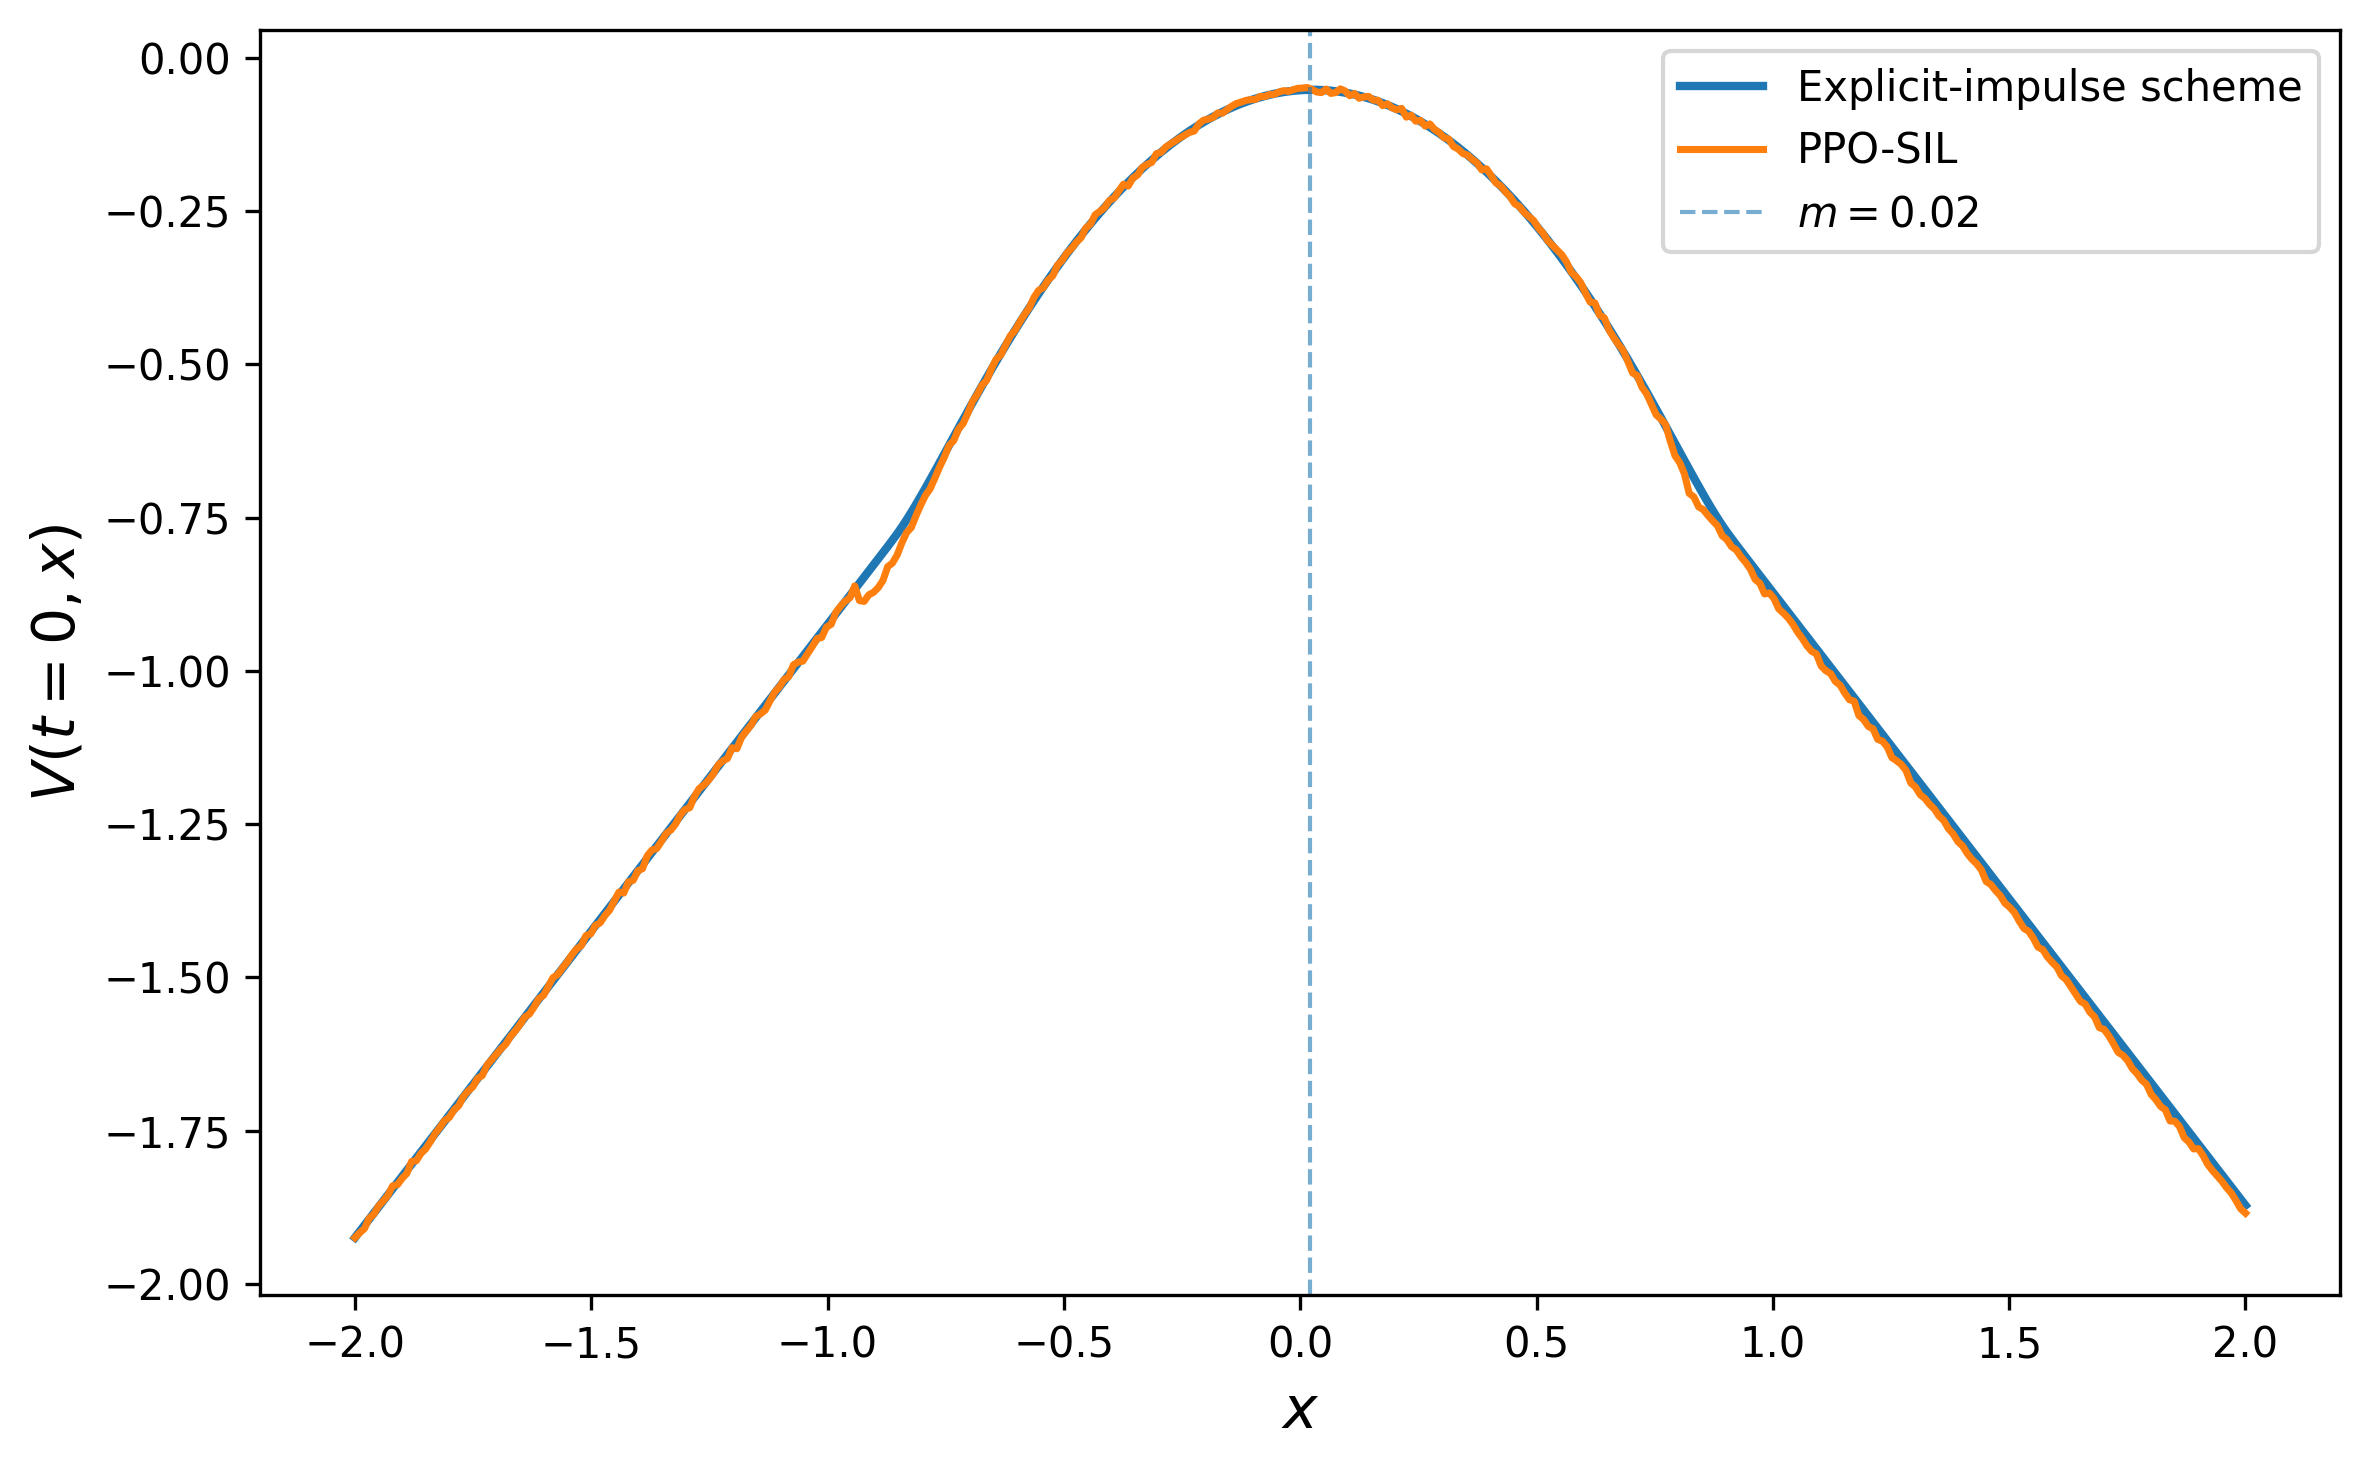

In [45]:
# 2D
fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=300)

# Scheme
ax.plot(x_grid, v_m_0, linewidth=2.0, label='Explicit-impulse scheme')

# PPO-SIL plot
ax.plot(PPO_MC_policy['x'], PPO_MC_policy['value'], linewidth=1.7, label='PPO-SIL')
# ax.fill_between(PPO_MC_policy['x'], PPO_MC_policy['value'] - 1.96*PPO_MC_policy['std'], PPO_MC_policy['value'] + 1.96*PPO_MC_policy['std'], alpha=0.12, label=r'$\pm 2\,\mathrm{SE}$')

# m=0.02
ax.axvline(common['m'], linestyle='--', linewidth=1.0, alpha=0.6, label=r'$m=$0.02')

ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$V(t=0,x)$', fontsize=14)
#ax.set_title(r'Comparison of PPO-SIL and Explicit-impulse scheme value functions', fontsize=15)
ax.legend()
fig.tight_layout()
plt.show()

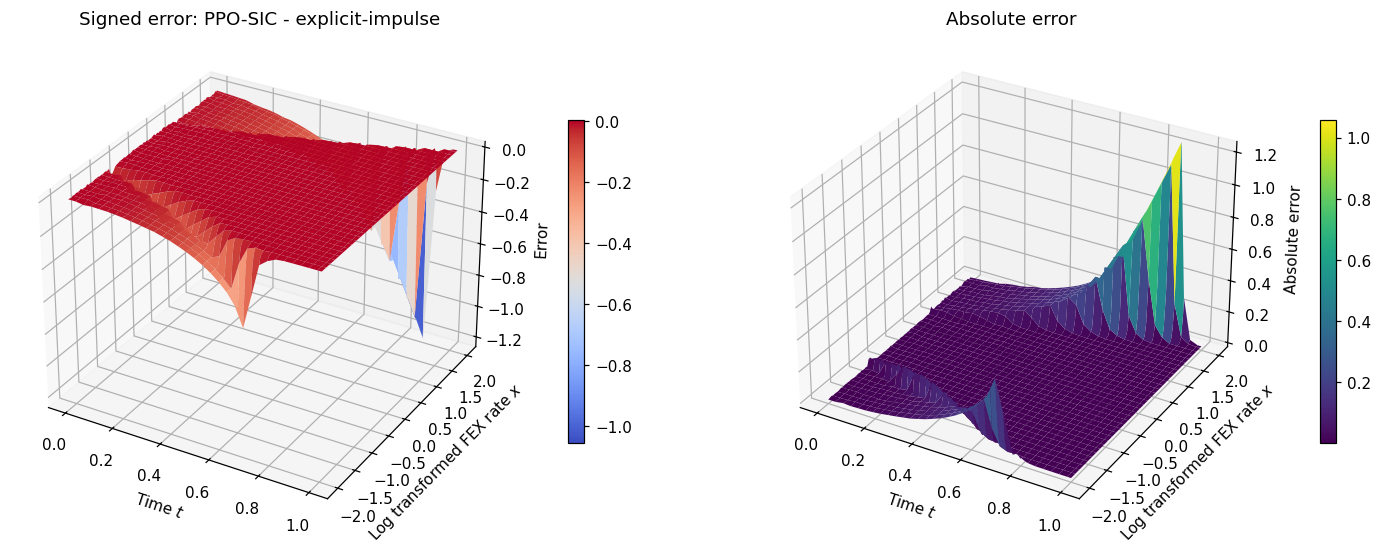

In [ ]:
signed_error_plot_PPO = V_ppo_mc_plot - V_explicit_plot_PPO
abs_error_plot_PPO = np.abs(signed_error_plot_PPO)

fig = plt.figure(figsize=(14, 5), dpi=110)

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(
    T_meshgrid_plot_PPO,
    X_meshgrid_plot_PPO,
    signed_error_plot_PPO,
    cmap='coolwarm',
    linewidth=0,
    antialiased=True,
)
ax1.set_title('Signed error: PPO-SIC - explicit-impulse')
ax1.set_xlabel(r'$t$')
ax1.set_ylabel(r'$x$')
ax1.set_zlabel('Error')
fig.colorbar(surf1, ax=ax1, shrink=0.65, pad=0.08)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(
    T_meshgrid_plot_PPO,
    X_meshgrid_plot_PPO,
    abs_error_plot_PPO,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
)
ax2.set_title('Absolute error')
ax2.set_xlabel(r'$t$')
ax2.set_ylabel(r'$x$')
ax2.set_zlabel('Absolute error')
fig.colorbar(surf2, ax=ax2, shrink=0.65, pad=0.08)

plt.tight_layout()
plt.show()

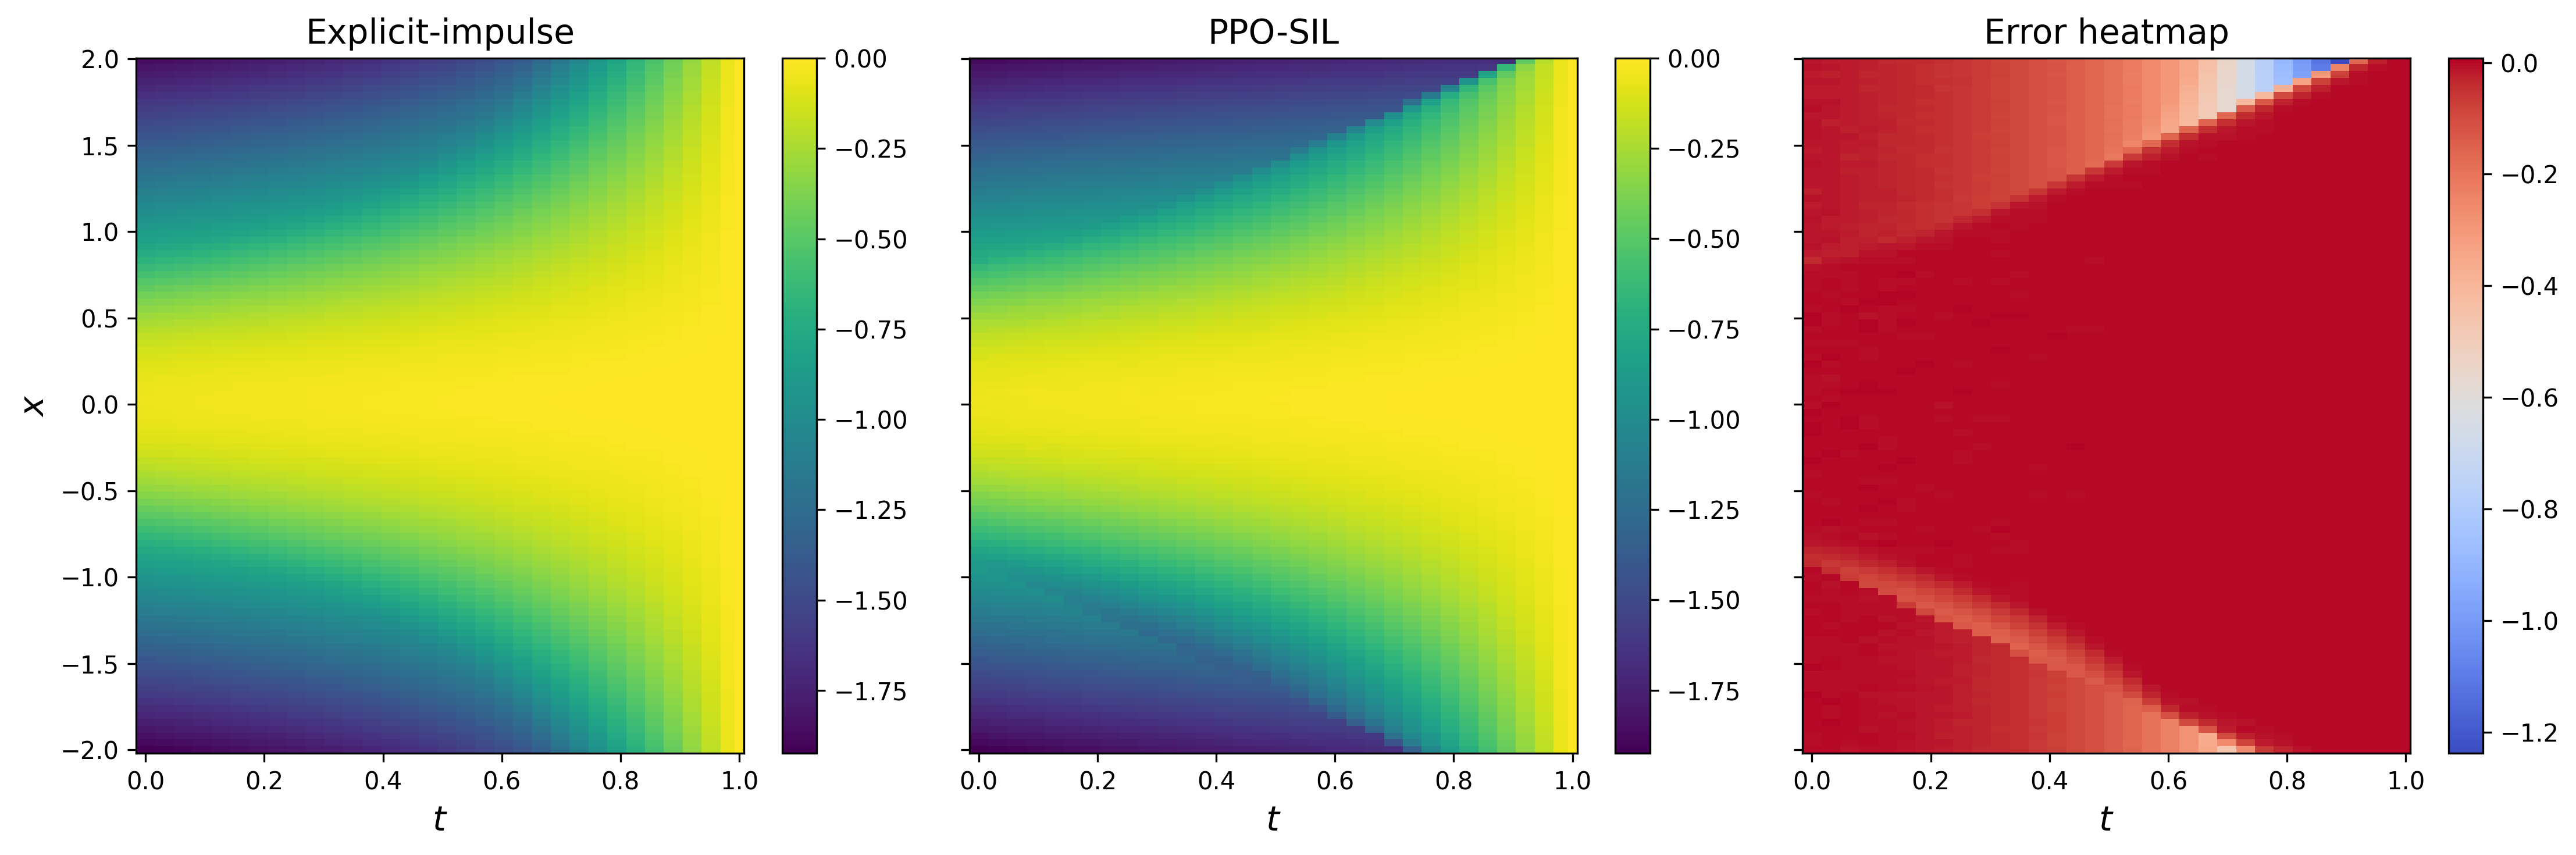

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), dpi=300, sharey=True)

im0 = axs[0].pcolormesh(
    t_grid_plot_PPO,
    x_grid_plot_PPO,
    V_explicit_plot_PPO.T,
    shading='auto',
    cmap='viridis',
)
axs[0].set_title('Explicit-impulse', fontsize=14)
axs[0].set_xlabel(r'$t$', fontsize=14)
axs[0].set_ylabel(r'$x$', fontsize=14)
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].pcolormesh(
    t_grid_plot_PPO,
    x_grid_plot_PPO,
    V_ppo_mc_plot.T,
    shading='auto',
    cmap='viridis',
)
axs[1].set_title('PPO-SIL', fontsize=14)
axs[1].set_xlabel(r'$t$', fontsize=14)
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].pcolormesh(
    t_grid_plot_PPO,
    x_grid_plot_PPO,
    signed_error_plot_PPO.T,
    shading='auto',
    cmap='coolwarm',
)
axs[2].set_title('Error heatmap', fontsize=14)
axs[2].set_xlabel(r'$t$', fontsize=14)
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()